# 8. Core Microbiota Analysis
In this notebook, the goal is to understand how the core microbiota differs between groups of children defined by different metadata variables, such as geographic location, delivery mode, feeding pattern, and treatment exposure. The core microbiota refers to the genera that are present in a large fraction of individuals within a group. Identifying core taxa helps highlight which microbes are typical or characteristic for each group.

To study this, the feature table is first processed by rarefying the data, and collapsing the table to the genus level. After this preprocessing, the table is split into subgroups based on the selected metadata variable (e.g., breast-fed vs formula-fed, vaginal vs C-section, exposed vs non-exposed). Core features are then calculated for each group across a range of prevalence thresholds. Exploring different thresholds allows us to see which genera remain stable across individuals and which quickly disappear as the “core” definition becomes stricter.

Finally, the core microbiota of the groups is compared to determine which genera are shared across all children and which are unique to specific metadata categories. This provides a clearer picture of how different biological or environmental factors (feeding type, delivery mode, treatment exposure, or geographic background) shape the typical microbiome composition in early childhood.

### Notebook Structure
**0.** Setup

**1.** Core Extraction and Table Preparation

**2.** Exploring Core Thresholds

&nbsp;&nbsp;&nbsp;&nbsp;**2.1** Core Size per Group

&nbsp;&nbsp;&nbsp;&nbsp;**2.2** Core Size Compared Between Groups

**3.** Core Taxa Comparison Using Heatmap Between Groups

**4.** Collecting Results and Comparing Core Microbiota Across Metadata Groups

<div style="border: 2px solid #1f77b4; padding: 10px; border-radius: 6px; background-color: #eaf3fb;">
<b> Research question this notebook answers:</b>

- How does the core microbiota differ between groups defined by metadata variables such as feeding pattern, delivery mode, and treatment exposure?

</div>


## 0. Setup

In [5]:
# Import all necessary packages
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import seaborn as sns
import os
from qiime2 import Visualization
from ipywidgets import Dropdown, VBox, HBox
from IPython.display import Image, display

%matplotlib inline

In [6]:
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [7]:
# Data directories
meta_data_dir = "../data/processed/metadata"
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
core_microbiota_dir = "../data/processed/core_microbiota"

# Create directories
!mkdir -p $core_microbiota_dir \
         $core_microbiota_dir/processed_tables

### Set run and metric to work with

The interactive widgets below allow you to configure how the core microbiota analysis is performed. First, you can choose the taxonomic level at which the microbiome will be analyzed, for example phylum, family, or genus. This determines how detailed the microbial classification will be in the downstream analysis.
Next, you select a metadata variable that is used to split the samples into groups. Examples include geographic location, delivery mode, feeding pattern, or treatment exposure.

After choosing a metadata variable, two dropdown menus appear that let you select exactly two groups to compare. This is important because the core microbiota analysis in this notebook is designed to compare two groups at a time. For each comparison, we evaluate which taxa are core in the first group, core in the second group, or shared between both groups. Comparisons involving more than two groups are therefore not supported in this workflow.

The dropdowns are filled automatically with analysis on diet as studied in the main project, but all selections can be changed to explore different comparisons.

In [4]:
# Load metadata table
metadata = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# Taxonomic levels the user can choose from
tax_levels = ["phylum", "class", "order", "family", "genus", "species"]

tax_selector = Dropdown(
    options=tax_levels,
    value="genus",  # default choice
    description="Tax level:"
)

# Metadata columns that are categorical and suitable for grouping
categorical_cols = ["geo_location_name", "delivery_mode", "diet_milk", "treatment_exposure"]

meta_selector = Dropdown(
    options=sorted(categorical_cols),
    value="diet_milk",    # default grouping variable
    description="Metadata:"
)

# Dropdowns for selecting the two groups to compare
group1_selector = Dropdown(description="Group 1:")
group2_selector = Dropdown(description="Group 2:")

def update_groups(change=None):
    # Get all unique values for the selected metadata column
    col = meta_selector.value
    vals = sorted(metadata[col].dropna().unique().tolist())

    group1_selector.options = vals
    group2_selector.options = vals

    # Pick sensible default groups (first two categories)
    if len(vals) >= 2:
        group1_selector.value = vals[0]
        group2_selector.value = vals[1]
    elif len(vals) == 1:
        group1_selector.value = vals[0]
        group2_selector.value = vals[0]

# Update groups whenever the metadata column selection changes
meta_selector.observe(update_groups, names="value")

# Initial population of the dropdowns
update_groups()

# Display the widget interface
VBox([
    tax_selector,
    meta_selector,
    HBox([group1_selector, group2_selector])
])

In [5]:
# Read current selections from the widgets
selected_level = tax_selector.value
group_col = meta_selector.value
group1 = group1_selector.value
group2 = group2_selector.value

# Convenience list for filtering and looping
groups = [group1, group2]

## 1. Core Extraction and Table Preparation

In this section, we prepare the feature table for core microbiota analysis. The goal is to obtain a standardized table in which samples are comparable and very rare, potentially noisy features are removed.
Next, extremely low-abundance features are filtered out. Very rare taxa are often inconsistent across samples and may represent sequencing noise rather than stable biological signals. Removing these features simplifies the dataset and improves the interpretability of the core microbiota results. Finally, the processed table will be collapsed to the genus level in later steps and used as the basis for all downstream comparisons between metadata-defined groups.

In [6]:
# File paths
metadata_fp = f"{meta_data_dir}/metadata_merged.tsv"
feature_table_fp = f"{taxonomy_data_dir}/dada2_table_filtered.qza"
taxonomy_fp = f"{taxonomy_data_dir}/taxonomy.qza"

First, the feature table is rarefied to an even sequencing depth. This step is used to reduce differences between samples that arise purely from technical variation in sequencing depth rather than from biological differences. Samples with higher sequencing depth are more likely to contain rare taxa simply because more reads were generated, which can bias presence and absence estimates.
Because the core microbiota analysis focuses on whether taxa are detected across many individuals, rather than on their exact abundances, equalizing sequencing depth helps ensure that taxa are compared fairly across samples. In this context, rarefaction provides a simple and transparent way to make detection probabilities more comparable between individuals. 

In [7]:
! qiime feature-table rarefy \
  --i-table "$feature_table_fp" \
  --p-sampling-depth 14000 \
  --o-rarefied-table {core_microbiota_dir}/processed_tables/rarefied_14k.qza

! echo "Rarefied table ready: rarefied_14k.qza"

QIIME is caching your current deployment for improved performance. This may take a few moments and should only happen once per deployment.
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/rarefied_14k.qza
Rarefied table ready: rarefied_14k.qza


After rarefaction, features are filtered based on their relative abundance. This step retains only features that reach at least 1 percent relative abundance in at least one sample. Very low-abundance taxa are often unstable across samples and may reflect background noise rather than biologically meaningful signals. Applying this filter helps focus the core microbiota analysis on taxa that are more consistently detected and more likely to be relevant for group comparisons

In [8]:
! qiime feature-table filter-features-conditionally \
  --i-table $core_microbiota_dir/processed_tables/rarefied_14k.qza \
  --p-abundance 0.01 \
  --p-prevalence 0 \
  --o-filtered-table $core_microbiota_dir/processed_tables/rarefied_14k_min01.qza

! echo "Low-abundance features removed. Table: rarefied_14k_min01.qza"

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/rarefied_14k_min01.qza
Low-abundance features removed. Table: rarefied_14k_min01.qza


After rarefaction and filtering, the feature table is collapsed to the selected taxonomic level using the taxonomy information. In this notebook, the default level is genus, which provides a balance between biological interpretability and robustness across samples. Collapsing the table reduces complexity by combining features that belong to the same taxon. This makes downstream core microbiota analysis easier to interpret and less sensitive to fine-scale variation at the ASV level.

In [9]:
# Map taxonomic labels to QIIME --p-level numbers
qiime_level_map = {
    "kingdom": 1,
    "phylum": 2,
    "class": 3,
    "order": 4,
    "family": 5,
    "genus": 6,
    "species": 7
}

# Use the widget's selection to compute the QIIME level
qiime_p_level = qiime_level_map[selected_level]

! qiime taxa collapse \
  --i-table $core_microbiota_dir/processed_tables/rarefied_14k_min01.qza \
  --i-taxonomy "$taxonomy_fp" \
  --p-level {qiime_p_level} \
  --o-collapsed-table $core_microbiota_dir/processed_tables/table_{selected_level}.qza

print(f"{selected_level} table ready: table_{selected_level}.qza")

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/table_genus.qza
genus table ready: table_genus.qza


In the next step, the collapsed feature table is split into separate tables based on the selected metadata variable. For example, when using the diet_milk column, samples are divided into breast-fed (bd) and formula-fed (fd) groups.

This separation is necessary because core microbiota analysis is performed within groups. A taxon is considered part of the core if it is present in a large fraction of individuals from the same group. Only after defining the core microbiota within each group can meaningful comparisons be made between groups.

In addition, the table is further split by age. Separating samples by age ensures that core microbiota comparisons are made between children at the same developmental stage. This is important because the dataset contains repeated samples from the same children at different ages. By analyzing each age separately, we reduce confounding by age and avoid mixing microbiome profiles from different stages of development.

In some cases, one of the groups may have no samples available at a given age. When this happens, QIIME may produce warnings or empty tables during filtering. This behavior is expected and does not indicate an error. These age–group combinations are skipped in later steps, because meaningful comparisons require at least two groups with available data. You can safely continue running the notebook even if such messages appear.

In [10]:
AGES = [4.0, 7.0, 10.0]

# Create a table for each category AND each age
for age in AGES:
    print(f"\n=== Processing age: {age} months ===")

    for value in groups:
        safe_value = str(value).replace(" ", "_").replace("/", "_")

        out_fp = (
            f"{core_microbiota_dir}/processed_tables/"
            f"table_{selected_level}_{group_col}_{safe_value}_age{int(age)}.qza"
        )

        print(f"Creating: {out_fp}")

        ! qiime feature-table filter-samples \
            --i-table $core_microbiota_dir/processed_tables/table_{selected_level}.qza \
            --m-metadata-file $metadata_fp \
            --p-where "{group_col}='{value}' AND age_months={age}" \
            --o-filtered-table {out_fp}


=== Processing age: 4.0 months ===
Creating: ../data/processed/core_microbiota/processed_tables/table_genus_treatment_exposure_True_age4.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/core_microbiota/processed_tables/table_genus_treatment_exposure_True_age4.qza
Creating: ../data/processed/core_microbiota/processed_tables/table_genus_treatment_exposure_False_age4.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Set

In this step, the core microbiota is calculated separately for each age group, but only when a valid comparison between metadata groups is possible. For each age in the dataset, the code first checks which group-specific feature tables actually exist. This is necessary because, at some ages, one of the metadata groups may have no samples available after filtering.

When at least two groups are available for a specific age, the core microbiota is calculated separately for each group using the core-features command. A minimum prevalence threshold of 50% is used, meaning that a taxon must be present in at least half of the samples within a group to be considered part of the core. The resulting visualizations summarize which taxa are consistently present within each group at that age.

In [11]:
# Loop over all ages that we want to analyze separately
for age in AGES:
    print(f"\n=== Checking core microbiota for age: {age} months ===")

    # This list will store which metadata groups actually exist for this age
    # We only want to continue if at least two groups are available
    existing_groups = []

    # Check for each metadata group whether a filtered table exists
    for value in groups:
        # Make group name safe for file paths
        safe_value = str(value).replace(" ", "_").replace("/", "_")

        # Path to the age- and group-specific feature table
        in_fp = (
            f"{core_microbiota_dir}/processed_tables/"
            f"table_{selected_level}_{group_col}_{safe_value}_age{int(age)}.qza"
        )

        # If the file exists, this group can be included in the comparison
        if os.path.exists(in_fp):
            existing_groups.append(value)

    # If fewer than two groups exist, skip this age
    # A core microbiota comparison requires at least two groups
    if len(existing_groups) < 2:
        print(
            f"Skipping age {age}: "
            f"only {len(existing_groups)} group(s) available "
            f"({existing_groups})"
        )
        continue

    # If we reach this point, at least two groups are available
    print(f"Proceeding with age {age}, groups: {existing_groups}")

    # Run the core-features analysis only for the valid groups
    for value in existing_groups:
        # Make group name safe for file paths
        safe_value = str(value).replace(" ", "_").replace("/", "_")

        # Input table for this group and age
        in_fp = (
            f"{core_microbiota_dir}/processed_tables/"
            f"table_{selected_level}_{group_col}_{safe_value}_age{int(age)}.qza"
        )

        # Output visualization showing core taxa at different prevalence thresholds
        out_fp = (
            f"{core_microbiota_dir}/"
            f"core_{selected_level}_{group_col}_{safe_value}_age{int(age)}_50.qzv"
        )

        print(f"Creating core features: {out_fp}")

        # Identify core taxa using a minimum prevalence of 50%
        # The visualization will also report higher thresholds
        ! qiime feature-table core-features \
            --i-table {in_fp} \
            --p-min-fraction 0.50 \
            --o-visualization {out_fp}

# Final message after processing all ages
print("Core microbiota visualizations created for all comparable ages.")


=== Checking core microbiota for age: 4.0 months ===
Proceeding with age 4.0, groups: [True, False]
Creating core features: ../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_50.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_50.qzv
Creating core features: ../data/processed/core_microbiota/core_genus_treatment_exposure_False_age4_50.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

## 2. Exploring Core Thresholds

In this section, we explore how the size of the core microbiota changes across different prevalence thresholds. The core-features analysis in QIIME does not produce a single fixed definition of the core. Instead, it reports which genera are present in at least a given fraction of samples, for example 50%, 60%, 70%, or higher. By examining multiple thresholds, we can see how robust each genus is across individuals.

Lower prevalence thresholds include genera that are common but not necessarily present in most children. As the threshold increases, only taxa that are consistently detected across many individuals remain in the core. This allows us to distinguish between genera that are broadly shared and those that are more variable or group-specific. Understanding this pattern helps interpret how strict the definition of “core microbiota” can be before most taxa drop out.

In this subsection, we first rely on the standard QIIME core-features output to inspect core taxa at different thresholds within each group. However, these results are shown separately for each group and threshold, which makes direct comparison difficult. Therefore, in Section 2.2 we extract and combine these results to create a single plot that shows how the number of core genera changes across thresholds for multiple groups at once. This combined visualization makes group differences and overall trends much easier to interpret.

### 2.1. Core Size per Group

In this subsection, we inspect the core microbiota results within each group and age separately, using the standard QIIME core-features visualizations. These plots show which genera qualify as core at different prevalence thresholds for a given group, such as breast-fed versus formula-fed children, at a specific age.

In [12]:
# Loop over all ages that are included in the analysis
for age in AGES:
    print(f"\n=== Showing core visualizations for age {age} months ===")

    # Loop over the selected groups (for example bd and fd)
    for value in groups:
        # Make the group name safe for file paths
        safe_value = str(value).replace(" ", "_").replace("/", "_")

        # Path to the core-features visualization for this group and age
        vis_fp = (
            f"{core_microbiota_dir}/"
            f"core_{selected_level}_{group_col}_{safe_value}_age{int(age)}_50.qzv"
        )

        # Only display the visualization if it exists
        # Missing files usually mean there were not enough samples for that group at this age
        if not os.path.exists(vis_fp):
            print(f"Skipping (not available): {value}, age {age}")
            continue

        print(f"Showing visualization for group: {value}, age {age}")

        # Load and display the QIIME2 visualization
        vis = Visualization.load(vis_fp)
        display(vis)


=== Showing core visualizations for age 4.0 months ===
Showing visualization for group: True, age 4.0


<visualization: Visualization uuid: 04d00a2e-eac5-4db0-988e-b742857618ff>

Showing visualization for group: False, age 4.0


<visualization: Visualization uuid: 59bfea34-0017-44bd-b618-00b113820bcc>


=== Showing core visualizations for age 7.0 months ===
Showing visualization for group: True, age 7.0


...

<visualization: Visualization uuid: 00d541eb-22a0-41fc-8881-784da545c530>


=== Showing core visualizations for age 10.0 months ===
Showing visualization for group: True, age 10.0


<visualization: Visualization uuid: 8cdadeee-11ee-4d1f-ad1b-994d88a55812>

Showing visualization for group: False, age 10.0


<visualization: Visualization uuid: 1aca1e9a-3b55-4db0-a347-190520271a81>

### 2.2. Core Size Compared Between Groups

In this step, the core-feature results are exported from QIIME2 so they can be analyzed and compared directly in Python. The core-features command produces .qzv visualization files, which are useful for inspection but not easy to compare quantitatively across groups.

By exporting these visualizations, we obtain plain TSV files that list which genera are considered core at different prevalence thresholds. Loading these files into Python allows us to compare core sizes between groups, visualize trends across thresholds, and examine how stable or variable the microbiota is within each metadata category.

As in earlier steps, this is done per age. Only ages where at least two groups are available are included, because meaningful comparisons require both groups to be present. If a group is missing at a certain age, that age is skipped automatically.

In [13]:
# Loop over all ages included in the analysis
for age in AGES:
    print(f"\n=== Checking exports for age {age} months ===")

    # Keep track of which groups have a core-features visualization at this age
    existing_groups = []

    for value in groups:
        # Make group name safe for file paths
        safe_value = str(value).replace(" ", "_").replace("/", "_")

        # Path to the core-features visualization
        in_fp = (
            f"{core_microbiota_dir}/"
            f"core_{selected_level}_{group_col}_{safe_value}_age{int(age)}_50.qzv"
        )

        # Only include groups for which the visualization exists
        if os.path.exists(in_fp):
            existing_groups.append(value)

    # Skip this age if fewer than two groups are available
    if len(existing_groups) < 2:
        print(
            f"Skipping age {age}: "
            f"only {len(existing_groups)} group(s) available "
            f"({existing_groups})"
        )
        continue

    print(f"Exporting core results for age {age}, groups: {existing_groups}")

    # Export core-feature results for each available group
    for value in existing_groups:
        safe_value = str(value).replace(" ", "_").replace("/", "_")

        in_fp = (
            f"{core_microbiota_dir}/"
            f"core_{selected_level}_{group_col}_{safe_value}_age{int(age)}_50.qzv"
        )

        out_dir = (
            f"{core_microbiota_dir}/"
            f"core_{selected_level}_{group_col}_{safe_value}_age{int(age)}_export"
        )

        print(f"Exporting: {in_fp} → {out_dir}")

        # Export the QIIME2 visualization to a directory containing TSV files
        ! qiime tools export \
            --input-path {in_fp} \
            --output-path {out_dir}

        print(f"Export complete for group: {value}, age {age}\n")


=== Checking exports for age 4.0 months ===
Exporting core results for age 4.0, groups: [True, False]
Exporting: ../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_50.qzv → ../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_export
Exported ../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_50.qzv as Visualization to directory ../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_export
Export complete for group: True, age 4.0

Exporting: ../data/processed/core_microbiota/core_genus_treatment_exposure_False_age4_50.qzv → ../data/processed/core_microbiota/core_genus_treatment_exposure_False_age4_export
Exported ../data/processed/core_microbiota/core_genus_treatment_exposure_False_age4_50.qzv as Visualization to directory ../data/processed/core_microbiota/core_genus_treatment_exposure_False_age4_export
Export complete for group: False, age 4.0


=== Checking exports for age 7.0 months ===
Exporting c

In this step, the exported core-feature results are loaded into Python so they can be analyzed further. Each exported directory contains multiple TSV files, one for each prevalence threshold used by the core-features command.
The helper function below reads a single TSV file while handling some common formatting issues. QIIME2 core-feature tables often include comment lines at the top and may contain empty rows. These are removed during loading. Each valid table must include a Feature ID column, which lists the taxa that qualify as core at that specific threshold.

The code then loops over all ages and metadata groups. For each age, it first checks which groups have exported core-feature results. Only ages where at least two groups are available are kept, because later comparisons require two groups. For those valid age–group combinations, all core-feature TSV files are collected and stored in a nested dictionary structure for easy access in later steps.

In [14]:
# This function loads a single core-feature TSV file exported from QIIME2.
# It skips comment lines, removes empty rows, and checks that a Feature ID
# column is present.
def load_core_file(path):
    df = pd.read_csv(
        path,
        sep="\t",
        comment="#",
        dtype=str
    ).dropna(how="all")

    if "Feature ID" not in df.columns:
        raise ValueError(f"'Feature ID' column missing in: {path}")
    return df


# Dictionary to store paths to core-feature files
# Structure: { age : { group : [list of TSV files] } }
core_files = {}

# Loop over all ages included in the analysis
for age in AGES:
    print(f"\n=== Loading core-feature files for age {age} months ===")

    age_dict = {}

    # First, identify which groups have exported core results at this age
    existing_groups = []

    for value in groups:
        safe = str(value).replace(" ", "_").replace("/", "_")

        export_dir = (
            f"{core_microbiota_dir}/"
            f"core_{selected_level}_{group_col}_{safe}_age{int(age)}_export"
        )

        if os.path.exists(export_dir):
            existing_groups.append(value)

    # Skip this age if fewer than two groups are available
    if len(existing_groups) < 2:
        print(
            f"Skipping age {age}: "
            f"only {len(existing_groups)} group(s) available "
            f"({existing_groups})"
        )
        continue

    print(f"Processing age {age}, groups: {existing_groups}")

    # Collect core-feature TSV files for each valid group
    for value in existing_groups:
        safe = str(value).replace(" ", "_").replace("/", "_")

        pattern = (
            f"{core_microbiota_dir}/"
            f"core_{selected_level}_{group_col}_{safe}_age{int(age)}_export/"
            f"core-features-*.tsv"
        )

        files = sorted(glob.glob(pattern))
        age_dict[value] = files

        print(f"{value}: {files}")

    # Store results for this age
    core_files[age] = age_dict


=== Loading core-feature files for age 4.0 months ===
Processing age 4.0, groups: [True, False]
True: ['../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_export/core-features-0.500.tsv', '../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_export/core-features-0.550.tsv', '../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_export/core-features-0.600.tsv', '../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_export/core-features-0.650.tsv', '../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_export/core-features-0.700.tsv', '../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_export/core-features-0.750.tsv', '../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_export/core-features-0.800.tsv', '../data/processed/core_microbiota/core_genus_treatment_exposure_True_age4_export/core-features-0.850.tsv']
False: ['../data/processed/core_

In this step, the exported core-feature tables are converted into structured Python dictionaries that make it easy to analyze and visualize the results. Each core-feature file corresponds to a specific prevalence threshold and contains the taxa that are considered core at that threshold.

For each age, the code first checks which groups (for example BD and FD) have available core-feature exports. Only ages with at least two groups are kept, because meaningful comparisons require two groups. For each valid group, all core-feature TSV files are loaded and stored in a dictionary where the key is the prevalence threshold and the value is the corresponding table of core taxa.

In addition to storing the full tables, the code also calculates how many core genera are present at each threshold. These counts summarize how the size of the core microbiota changes as the definition of “core” becomes more strict. The resulting structures are used in the next sections to create line plots and heatmaps that compare core microbiota stability between groups.

In [15]:
# Dictionary to store core-feature tables
# Structure: { age : { group : { threshold : DataFrame } } }
core_data = {}

# Dictionary to store the number of core taxa per threshold
# Structure: { age : { group : { threshold : count } } }
threshold_counts = {}

# Loop over all ages included in the analysis
for age in AGES:
    print(f"\n=== Building core data for age {age} months ===")
    age_core = {}

    # First, check which groups have exported core-feature results at this age
    existing_groups = []

    for g in groups:
        safe = str(g).replace(" ", "_").replace("/", "_")

        export_dir = (
            f"{core_microbiota_dir}/"
            f"core_{selected_level}_{group_col}_{safe}_age{int(age)}_export"
        )

        if os.path.exists(export_dir):
            existing_groups.append(g)

    # Skip this age if fewer than two groups are available
    if len(existing_groups) < 2:
        print(
            f"Skipping age {age}: "
            f"only {len(existing_groups)} group(s) available "
            f"({existing_groups})"
        )
        continue

    print(f"Processing age {age}, groups: {existing_groups}")

    # Load core-feature tables for each valid group
    for g in existing_groups:
        safe = str(g).replace(" ", "_").replace("/", "_")

        pattern = (
            f"{core_microbiota_dir}/"
            f"core_{selected_level}_{group_col}_{safe}_age{int(age)}_export/"
            f"core-features-*.tsv"
        )

        files = sorted(glob.glob(pattern))

        group_dict = {}

        # Each file corresponds to one prevalence threshold
        for f in files:
            # Extract the threshold value from the filename
            thr = float(re.findall(r"core-features-(.*).tsv", f)[0])

            # Load the core-feature table for this threshold
            group_dict[thr] = load_core_file(f)

        age_core[g] = group_dict

    # Store all core-feature tables for this age
    core_data[age] = age_core

    # Also compute the number of core taxa at each threshold
    threshold_counts[age] = {
        g: {
            thr: len(df)
            for thr, df in age_core[g].items()
        }
        for g in age_core
    }


=== Building core data for age 4.0 months ===
Processing age 4.0, groups: [True, False]

=== Building core data for age 7.0 months ===
Processing age 7.0, groups: [True, False]

=== Building core data for age 10.0 months ===
Processing age 10.0, groups: [True, False]


This plot shows how the number of core genera changes as the prevalence threshold becomes more strict. At low thresholds, many genera qualify as core because they only need to be present in a small fraction of individuals. As the threshold increases, only genera that are consistently present across many children remain in the core, so the number of core taxa decreases.

By plotting all groups together for a given age, we can directly compare how stable the microbiota is across metadata categories. Groups with a slower decline retain more core genera even at high thresholds, suggesting a more consistent microbiome across individuals. Groups with a steep decline lose core taxa quickly, indicating greater variability between individuals. This analysis provides a high-level overview before focusing on which specific genera differ between groups.


Plotting core size for age 4.0 months


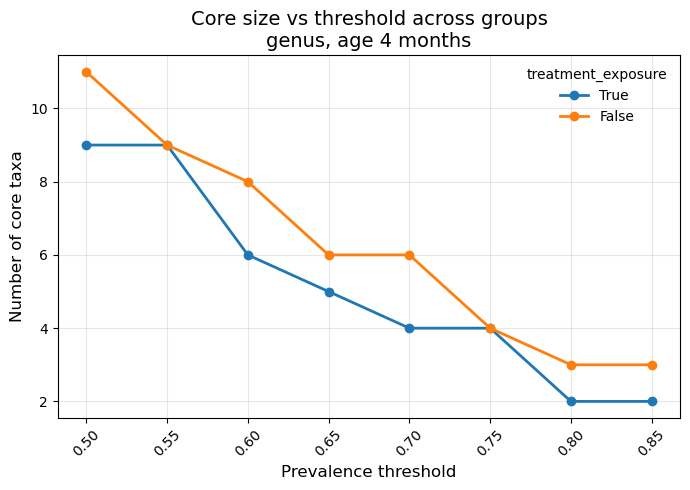


Plotting core size for age 7.0 months


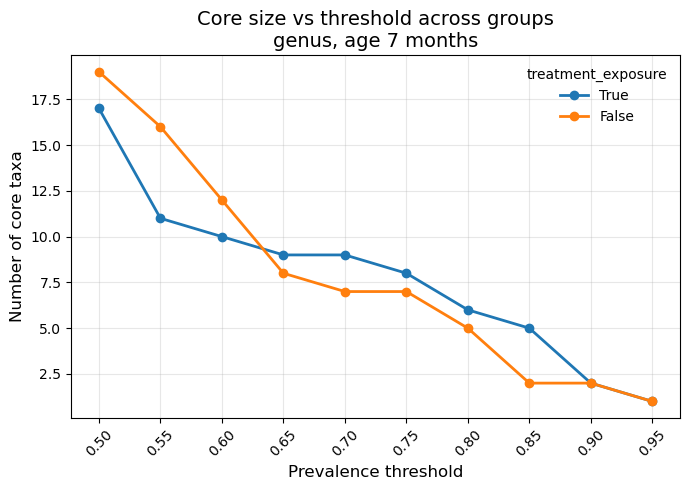


Plotting core size for age 10.0 months


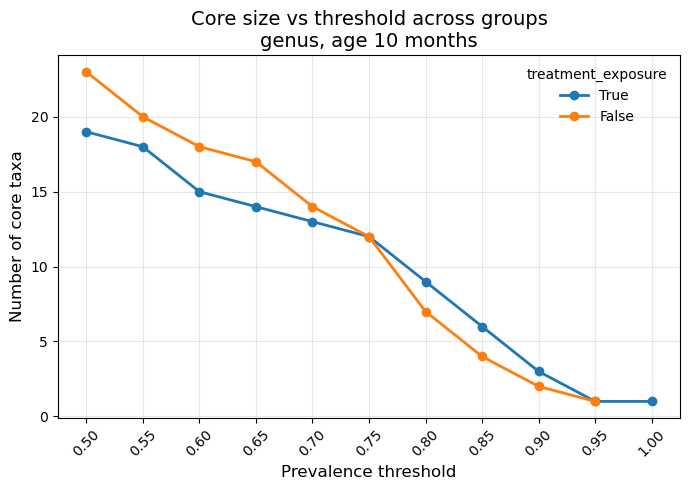

In [16]:
# Directory where figures will be saved
fig_dir = f"{core_microbiota_dir}/figures"
os.makedirs(fig_dir, exist_ok=True)

# Loop over ages and plot core size for each age separately
for age, age_counts in threshold_counts.items():
    print(f"\nPlotting core size for age {age} months")

    # Create a new figure for this age
    plt.figure(figsize=(7, 5))

    # Collect all thresholds used at this age
    # This ensures a consistent x-axis across groups
    all_thresholds = sorted(
        {thr for g in age_counts for thr in age_counts[g]}
    )

    # Plot one line per group
    for group, thr_dict in age_counts.items():
        thr = sorted(thr_dict.keys())
        counts = [thr_dict[t] for t in thr]

        plt.plot(
            thr,
            counts,
            marker="o",
            linewidth=2,
            label=str(group)
        )

    # Axis labels and title
    plt.xlabel("Prevalence threshold", fontsize=12)
    plt.ylabel("Number of core taxa", fontsize=12)
    plt.title(
        f"Core size vs threshold across groups\n"
        f"{selected_level}, age {int(age)} months",
        fontsize=14
    )

    # Improve readability
    plt.xticks(all_thresholds, rotation=45)
    plt.legend(title=group_col, frameon=False)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Export the figure (PNG + PDF)
    fname = (
        f"core_size_{selected_level}_{group_col}_"
        f"age{int(age)}"
    )

    plt.savefig(f"{fig_dir}/{fname}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{fig_dir}/{fname}.pdf", bbox_inches="tight")

    # Show the plot in the notebook
    plt.show()

## 3. Core Taxa Comparison Between Groups

In this section, we directly compare the core microbiota between groups to identify which genera are shared and which are group specific. While the previous section focused on how the size of the core microbiota changes across prevalence thresholds, here we focus on which taxa make up that core.

For each age, the core-feature results from the available groups are combined. A matrix is constructed that records whether a genus is core in one group only, in the other group only, in both groups, or in neither. This information is then visualized using a heatmap, which provides an intuitive overview of shared and group-specific core taxa across prevalence thresholds.

To keep the visualization readable, only the top taxa are shown. These are the taxa that appear in the core of at least one group at a moderately strict threshold. This approach highlights the most relevant differences between groups while avoiding clutter from very rare or unstable taxa.

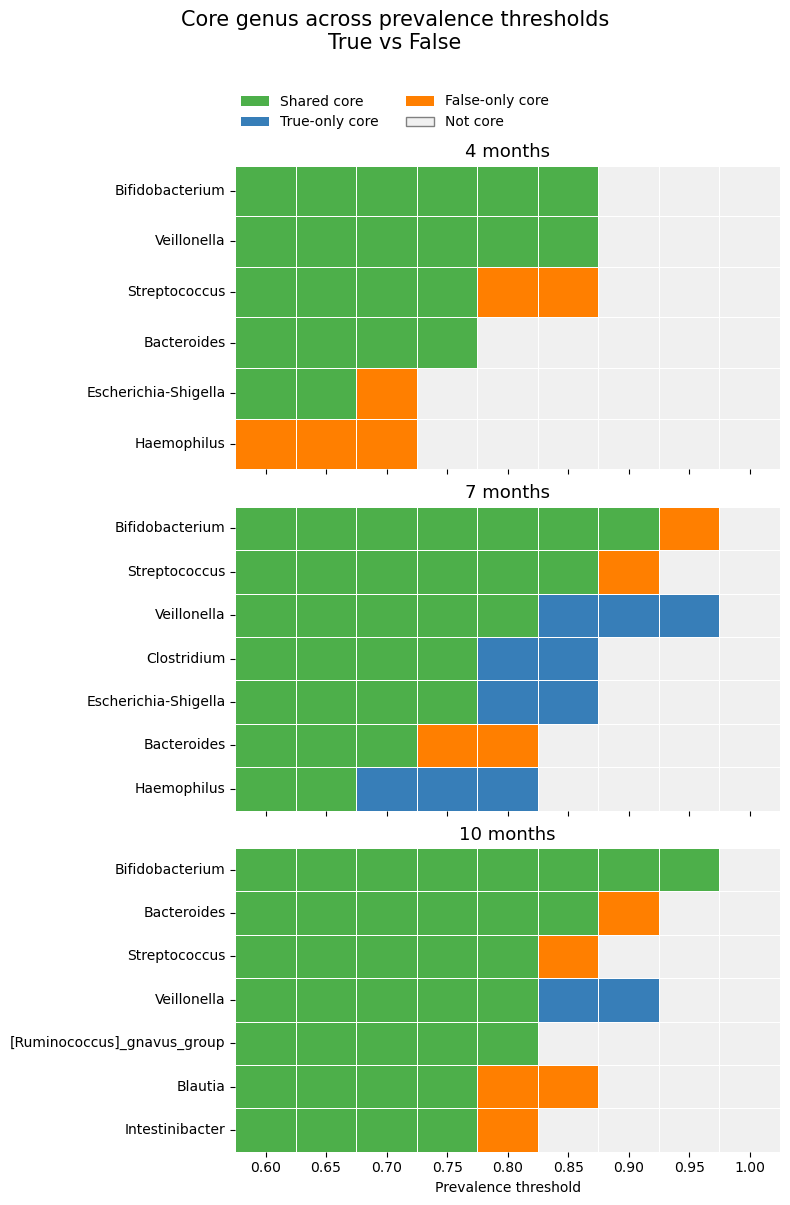

In [26]:
# This function extracts the name at the selected taxonomic level so that labels in the plots are readable and consistent
def extract_taxon(taxon_str, level):
    prefixes = {
        "phylum":  "p__",
        "class":   "c__",
        "order":   "o__",
        "family":  "f__",
        "genus":   "g__",
        "species": "s__"
    }

    prefix = prefixes[level]

    # If the expected prefix is missing, mark the taxon as unassigned
    if prefix not in taxon_str:
        return "Unassigned"

    # Return the part of the string after the prefix
    return taxon_str.split(prefix)[-1].strip()

# Decide which ages are available for plotting
# core_data has the structure:
# { age : { group : { prevalence_threshold : DataFrame } } }
# We create one heatmap panel per age.
ages_to_plot = list(core_data.keys())
n_ages = len(ages_to_plot)

# Create a vertically stacked figure with one subplot per age
fig, axes = plt.subplots(
    nrows=n_ages,
    ncols=1,
    figsize=(8, 4 * n_ages),
    sharex=True  # all panels use the same prevalence thresholds on the x-axis
)

# If there is only one age, make sure axes is still iterable
if n_ages == 1:
    axes = [axes]


# Step 1: determine global prevalence thresholds
# To make the x-axis comparable across ages, we first collect all prevalence thresholds that appear in any group
all_thresholds = set()

for age in ages_to_plot:
    age_core_data = core_data[age]

    # Only consider ages where at least two groups exist
    if len(age_core_data) < 2:
        continue

    group1, group2 = list(age_core_data.keys())[:2]

    all_thresholds |= set(age_core_data[group1].keys())
    all_thresholds |= set(age_core_data[group2].keys())

# Keep only thresholds ≥ 0.60 and sort them
all_thresholds = sorted(t for t in all_thresholds if t >= 0.60)
thr_labels = [f"{t:.2f}" for t in all_thresholds]


# Step 2: plot one heatmap per age (stacked vertically)
for ax, age in zip(axes, ages_to_plot):

    age_core_data = core_data[age]

    # Skip ages where fewer than two groups are available
    if len(age_core_data) < 2:
        ax.set_visible(False)
        continue

    # Select the two groups to compare
    group1, group2 = list(age_core_data.keys())[:2]
    g1 = age_core_data[group1]
    g2 = age_core_data[group2]

    # Define the cutoff used to select important taxa
    cutoff = 0.70

    # Skip this age if the cutoff threshold is not available
    if cutoff not in g1 or cutoff not in g2:
        ax.set_visible(False)
        continue

    # Identify taxa that are core in at least one group at the cutoff
    taxa = set(g1[cutoff]["Feature ID"]) | set(g2[cutoff]["Feature ID"])
    taxa_names = sorted(extract_taxon(t, selected_level) for t in taxa)

    # Create a matrix describing core status
    # 0 = not core
    # 1 = group1-only
    # 2 = group2-only
    # 3 = shared between groups
    status_df = pd.DataFrame(0, index=taxa_names, columns=thr_labels)

    for thr in all_thresholds:
        if thr not in g1 or thr not in g2:
            continue

        g1_tax = {extract_taxon(x, selected_level) for x in g1[thr]["Feature ID"]}
        g2_tax = {extract_taxon(x, selected_level) for x in g2[thr]["Feature ID"]}

        for name in taxa_names:
            if name in g1_tax and name in g2_tax:
                status_df.loc[name, f"{thr:.2f}"] = 3
            elif name in g1_tax:
                status_df.loc[name, f"{thr:.2f}"] = 1
            elif name in g2_tax:
                status_df.loc[name, f"{thr:.2f}"] = 2

    # Sort taxa so that similar core patterns appear together
    status_df["sort_key"] = status_df.values.tolist()
    status_df = status_df.sort_values("sort_key", ascending=False)
    status_df = status_df.drop(columns="sort_key")

    # Remove unassigned taxa for clarity
    status_df = status_df.drop(index="Unassigned", errors="ignore")

    # Limit to the top 7 taxa to keep the plot readable
    status_df = status_df.head(7)

    # Define colors for the four core-status categories
    cmap = ListedColormap([
        "#f0f0f0", # not core
        "#377eb8", # group1-only
        "#ff7f00", # group2-only
        "#4daf4a" # shared
    ])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

    # Plot the heatmap for this age
    sns.heatmap(
        status_df,
        ax=ax,
        cmap=cmap,
        norm=norm,
        cbar=False,
        linewidths=0.5,
        linecolor="white"
    )
    ax.set_title(f"{int(age)} months", fontsize=13)

# Only the bottom panel gets an x-axis label
axes[-1].set_xlabel("Prevalence threshold")

# Add shared legend and figure title
handles = [
    Patch(facecolor="#4daf4a", label="Shared core"),
    Patch(facecolor="#377eb8", label=f"{group1}-only core"),
    Patch(facecolor="#ff7f00", label=f"{group2}-only core"),
    Patch(facecolor="#f0f0f0", edgecolor="gray", label="Not core"),
]

# Place legend below the title
fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=2,
    frameon=False
)

# Main title for the entire figure
fig.suptitle(
    f"Core {selected_level} across prevalence thresholds\n"
    f"{group1} vs {group2}",
    fontsize=15,
    y=1
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Export the figure
# Save the plot as both PNG and PDF for later use
fig_dir = f"{core_microbiota_dir}/figures"
os.makedirs(fig_dir, exist_ok=True)

fname = (
    f"core_{selected_level}_{group_col}_"
    f"{group1}_vs_{group2}_stacked"
)

plt.savefig(f"{fig_dir}/{fname}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{fig_dir}/{fname}.pdf", bbox_inches="tight")

plt.show()

## 4. Collecting Results and Comparing Core Microbiota Across Metadata Groups

In this final section, the results from the core microbiota analysis are brought together and compared across selected metadata variables. For this comparison, we focus on treatment exposure, diet milk, and delivery mode. These variables were chosen because they define clear two-category groupings, which makes them well suited for direct core-microbiota comparisons.

The results shown here are obtained by running the same analysis pipeline multiple times, each time selecting a different metadata variable. By keeping all other parameters constant and only changing the grouping variable, the resulting core microbiota patterns can be compared in a consistent way. This allows us to assess whether and how different biological or environmental factors are associated with differences in the core microbiome during early childhood. We print all the images below to add overview and our interpretations.

In [12]:
core_microbiota_import_dir = f"{core_microbiota_dir}/imported_figures"

### 4.1. Comparing core microbiota of breast-fed and formula-fed infants

In [13]:
%%bash -s "$core_microbiota_import_dir"
mkdir -p "$1"


# import breast milk versus formula derived plots
wget --progress=bar:force:noscroll \
  -O "$1/core_genus_diet_milk_bd_vs_fd_stacked.png" \
  "https://polybox.ethz.ch/index.php/s/PF2gZkMHmgGfyJj/download"

wget --progress=bar:force:noscroll \
  -O "$1/core_size_genus_diet_milk_age4.png" \
  "https://polybox.ethz.ch/index.php/s/C6eij6b7nNcKXgN/download"

--2025-12-16 14:00:56--  https://polybox.ethz.ch/index.php/s/PF2gZkMHmgGfyJj/download
Resolving polybox.ethz.ch (polybox.ethz.ch)... 129.132.71.243
Connecting to polybox.ethz.ch (polybox.ethz.ch)|129.132.71.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 127888 (125K) [image/png]
Saving to: ‘../data/processed/core_microbiota/imported_figures/core_genus_diet_milk_bd_vs_fd_stacked.png’

../data/processed/c 100%[===================>] 124.89K  --.-KB/s    in 0.01s   

2025-12-16 14:00:56 (12.7 MB/s) - ‘../data/processed/core_microbiota/imported_figures/core_genus_diet_milk_bd_vs_fd_stacked.png’ saved [127888/127888]

--2025-12-16 14:00:56--  https://polybox.ethz.ch/index.php/s/C6eij6b7nNcKXgN/download
Resolving polybox.ethz.ch (polybox.ethz.ch)... 129.132.71.243
Connecting to polybox.ethz.ch (polybox.ethz.ch)|129.132.71.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149202 (146K) [image/png]
Saving to: ‘../data/processed/core_mic

Showing: core_size_genus_diet_milk_age4.png


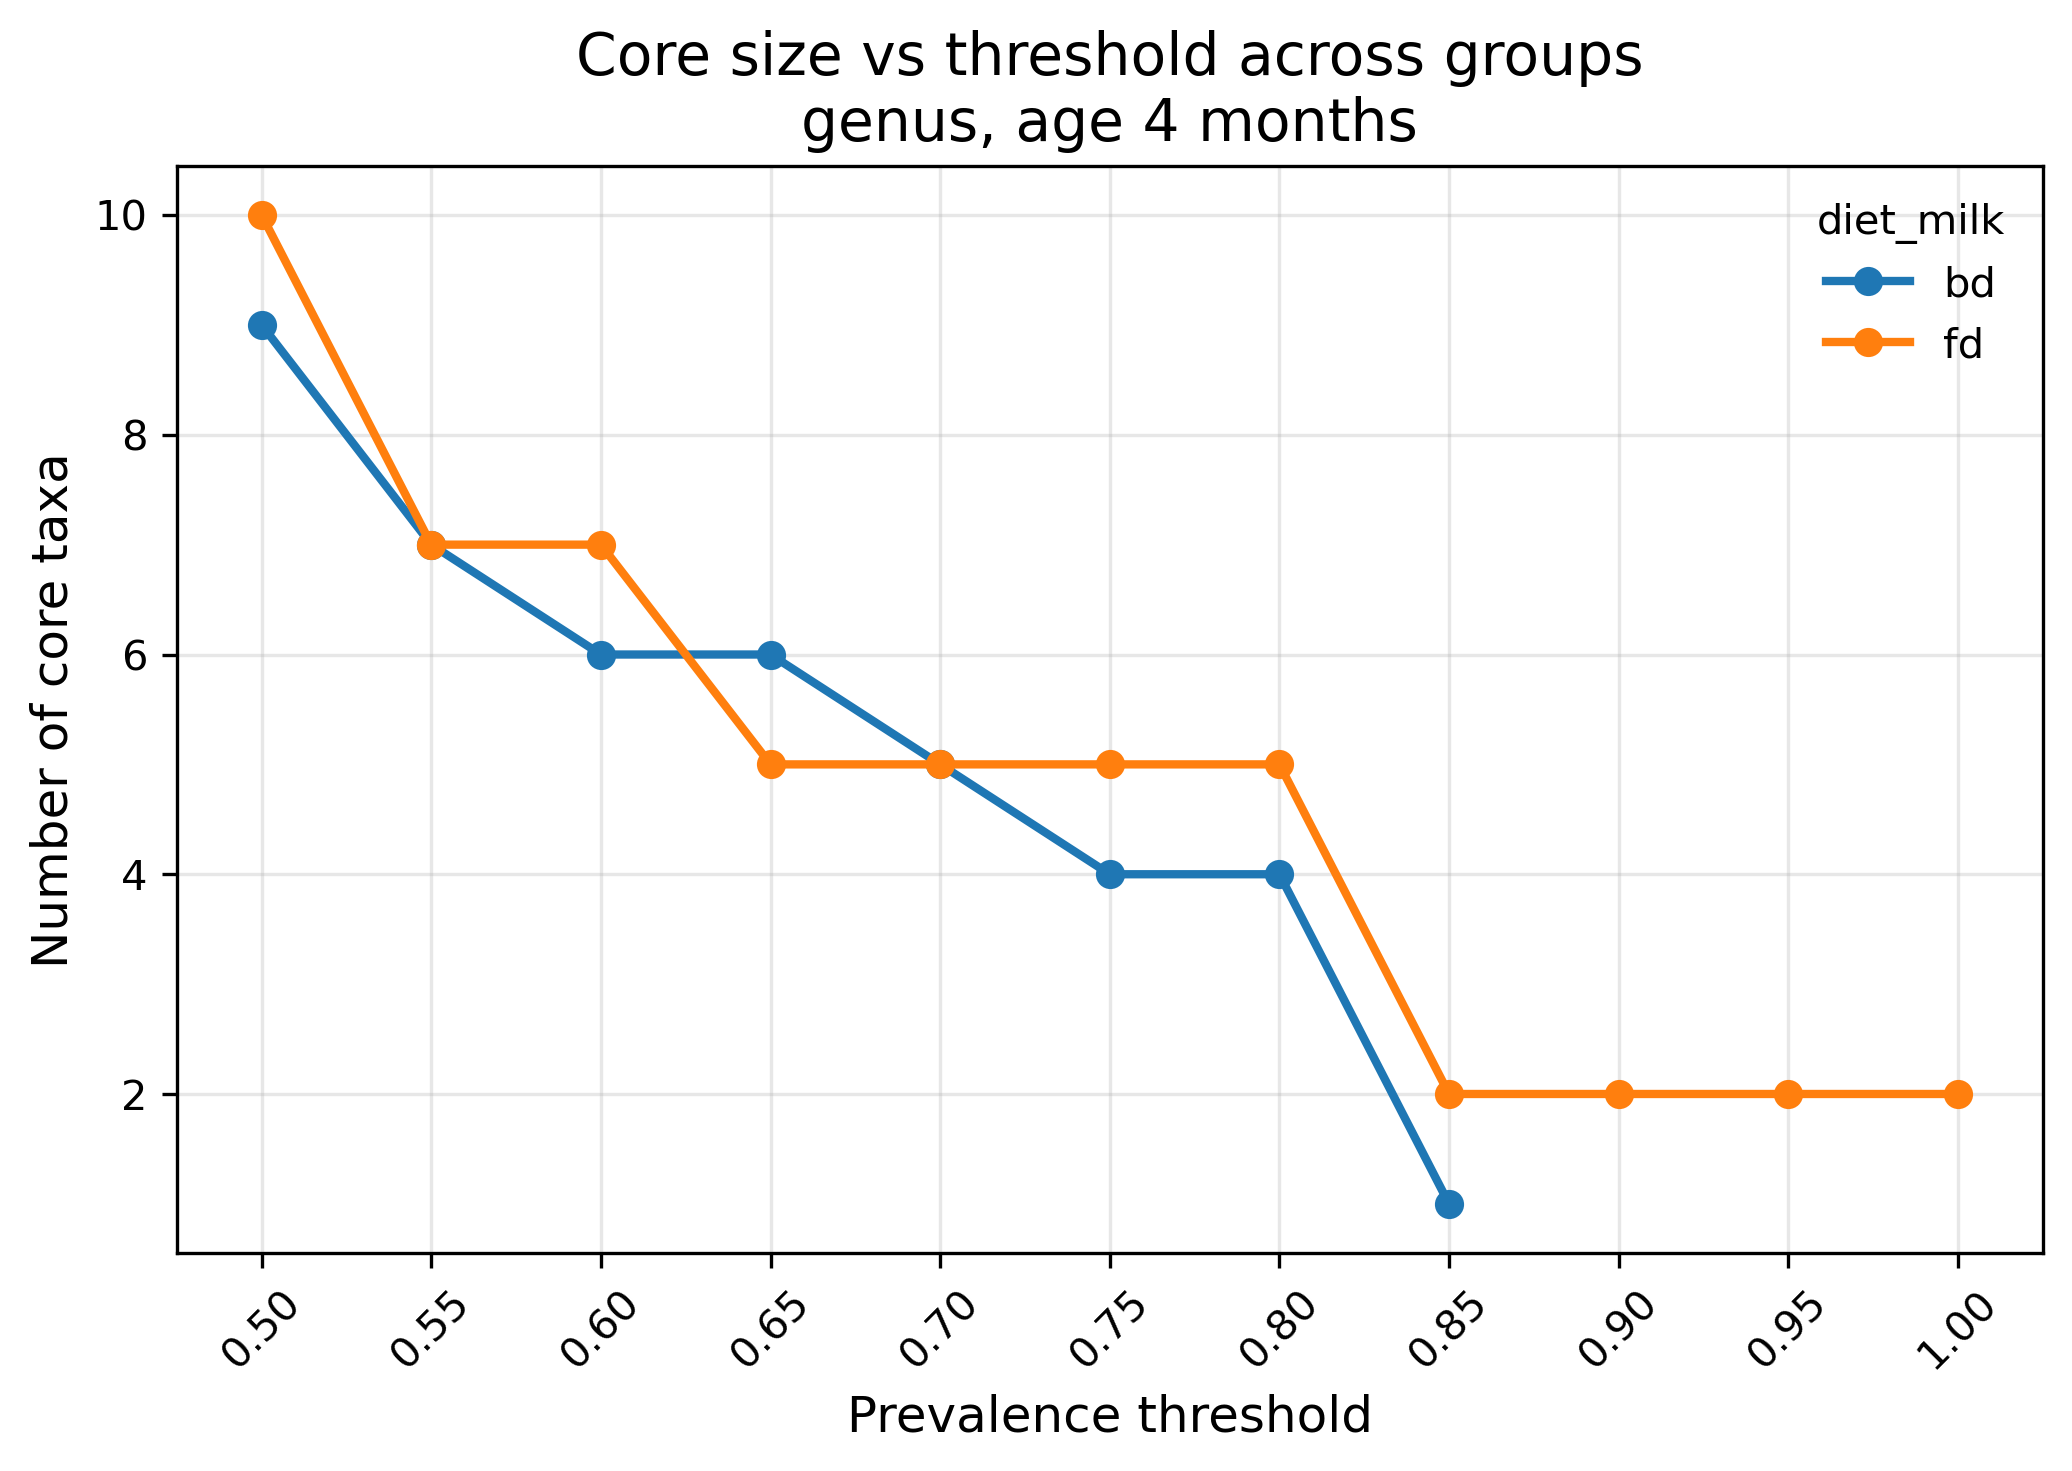

Showing: core_genus_diet_milk_bd_vs_fd_stacked.png


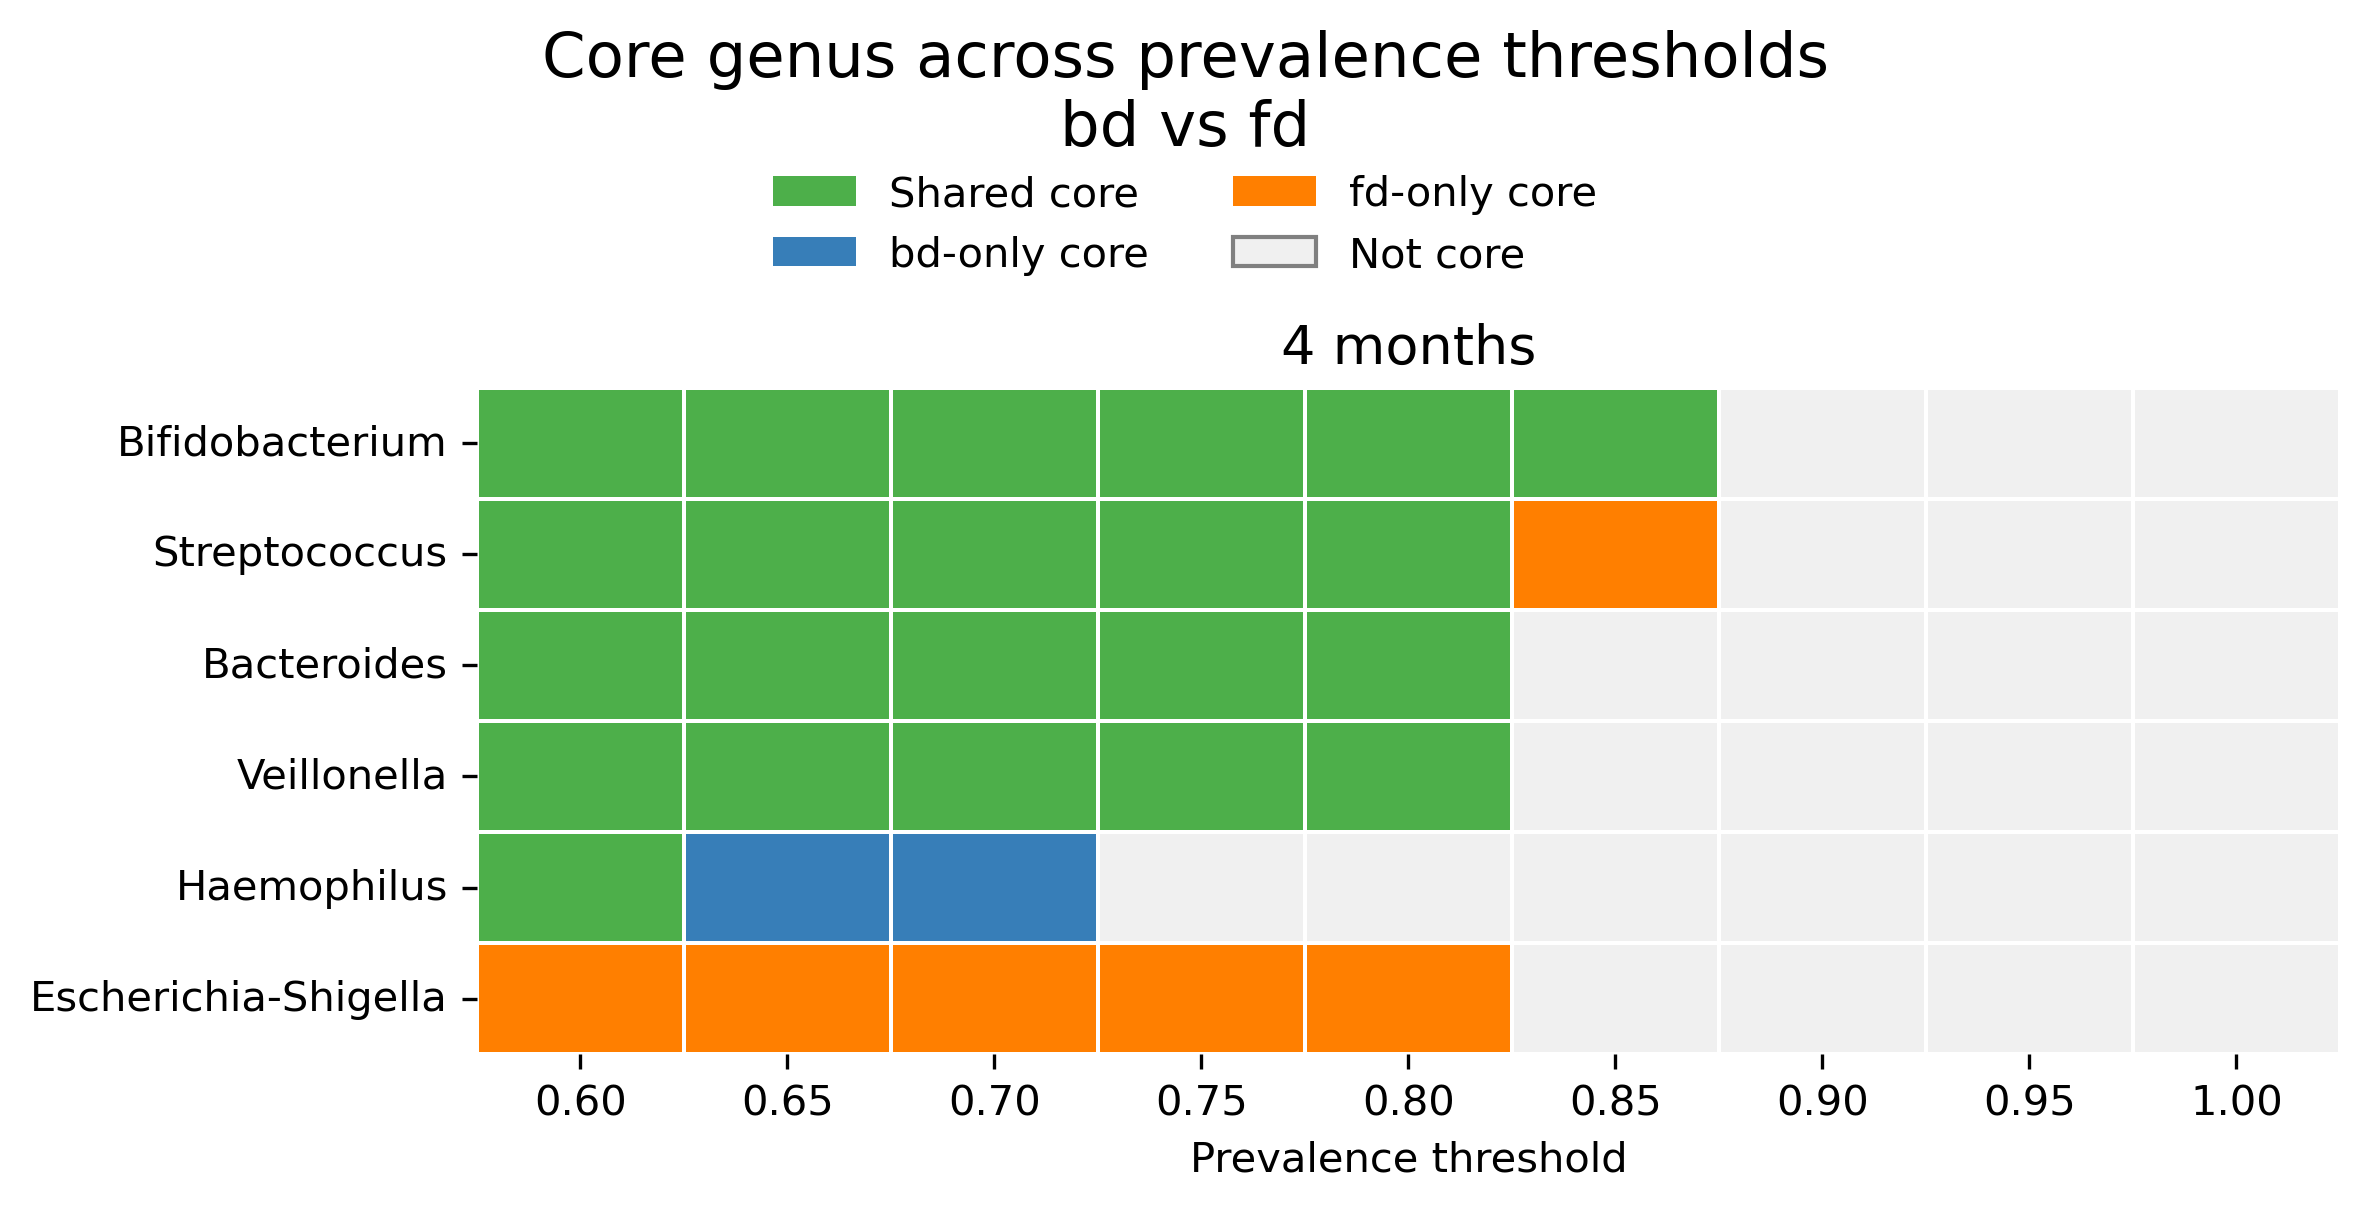

In [14]:
# List of downloaded image files
image_files = [
    "core_size_genus_diet_milk_age4.png",
    "core_genus_diet_milk_bd_vs_fd_stacked.png",
]

# Display each image
for fname in image_files:
    path = os.path.join(core_microbiota_import_dir, fname)
    print(f"Showing: {fname}")
    display(Image(filename=path, width=800)) # adjust if needed

The barplot above focuses on infants at 4 months of age, because after this time point almost all infants in the cohort are formula-fed, making comparisons with breastfed infants no longer possible. The results therefore describe early-life differences in the gut microbiome when feeding mode still varies.

Several genera, including Bifidobacterium, Bacteroides, Veillonella, and Streptococcus (which are also found to be abundant in [[Fehr et al., 2020](https://www.sciencedirect.com/science/article/pii/S1931312820303504)], appear as shared core taxa across a wide range of prevalence thresholds (approximately 60–80%). This suggests that these bacteria form a common early-life gut microbiome that is largely independent of feeding mode at this age. In contrast, Escherichia–Shigella is consistently identified as a formula-fed-only core genus up to a prevalence threshold of approximately 80%. This suggests a diet-associated difference, where formula feeding may favor this genus. However, limited information was found in the literature to directly support this observation, and the interpretation should therefore be treated with caution.

At very high prevalence thresholds (85–90%), almost no genera qualify as core taxa in either group, highlighting substantial variability between infants and showing that no genus is truly universal at 4 months of age.

### 4.2. Comparing core microbiota of infants with or without treatment

In [15]:
%%bash -s "$core_microbiota_import_dir"
mkdir -p "$1"

# import treatment or no treatment plots
wget --progress=bar:force:noscroll \
  -O "$1/core_genus_treatment_exposure_True_vs_False_stacked.png" \
  "https://polybox.ethz.ch/index.php/s/3xkbrGAj6do9GW8/download"

wget --progress=bar:force:noscroll \
  -O "$1/core_size_genus_treatment_exposure_age4.png" \
  "https://polybox.ethz.ch/index.php/s/ixQeSj87qn6rd5C/download"

wget --progress=bar:force:noscroll \
  -O "$1/core_size_genus_treatment_exposure_age7.png" \
  "https://polybox.ethz.ch/index.php/s/xWmJkcqSWqktHqc/download"

wget --progress=bar:force:noscroll \
  -O "$1/core_size_genus_treatment_exposure_age10.png" \
  "https://polybox.ethz.ch/index.php/s/C3RNHqa3BF7soD9/download"

--2025-12-16 14:00:58--  https://polybox.ethz.ch/index.php/s/3xkbrGAj6do9GW8/download
Resolving polybox.ethz.ch (polybox.ethz.ch)... 129.132.71.243
Connecting to polybox.ethz.ch (polybox.ethz.ch)|129.132.71.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 270290 (264K) [image/png]
Saving to: ‘../data/processed/core_microbiota/imported_figures/core_genus_treatment_exposure_True_vs_False_stacked.png’

../data/processed/c 100%[===================>] 263.96K  --.-KB/s    in 0.002s  

2025-12-16 14:00:58 (118 MB/s) - ‘../data/processed/core_microbiota/imported_figures/core_genus_treatment_exposure_True_vs_False_stacked.png’ saved [270290/270290]

--2025-12-16 14:00:58--  https://polybox.ethz.ch/index.php/s/ixQeSj87qn6rd5C/download
Resolving polybox.ethz.ch (polybox.ethz.ch)... 129.132.71.243
Connecting to polybox.ethz.ch (polybox.ethz.ch)|129.132.71.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 158152 (154K) [image/png]
Saving to: 

Showing: core_size_genus_treatment_exposure_age4.png


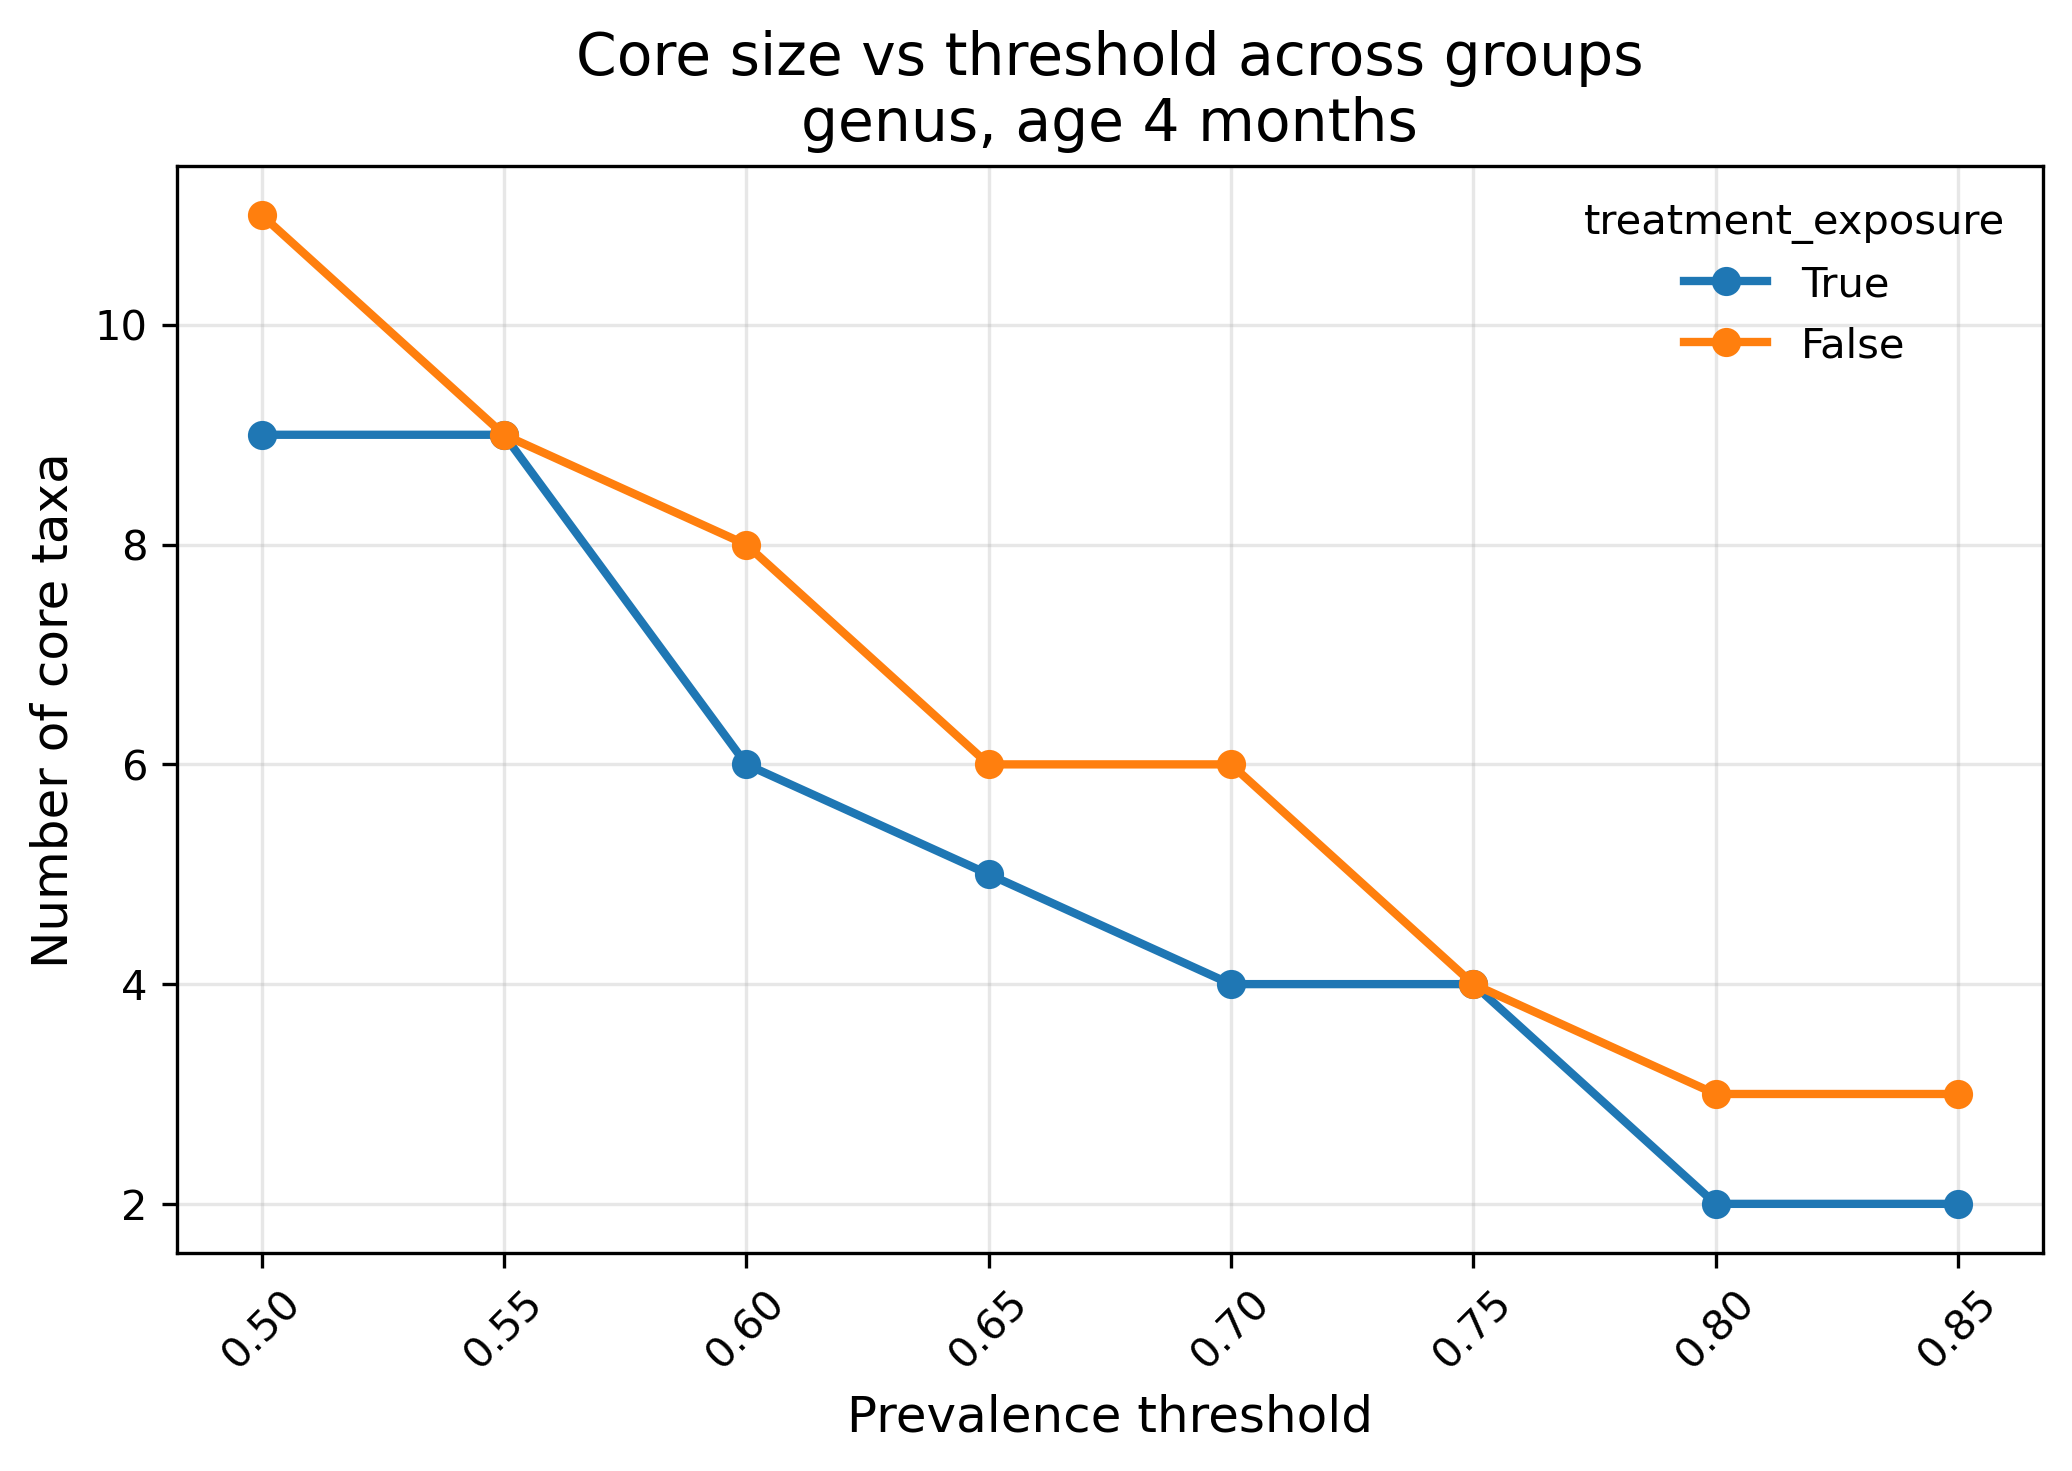

Showing: core_size_genus_treatment_exposure_age7.png


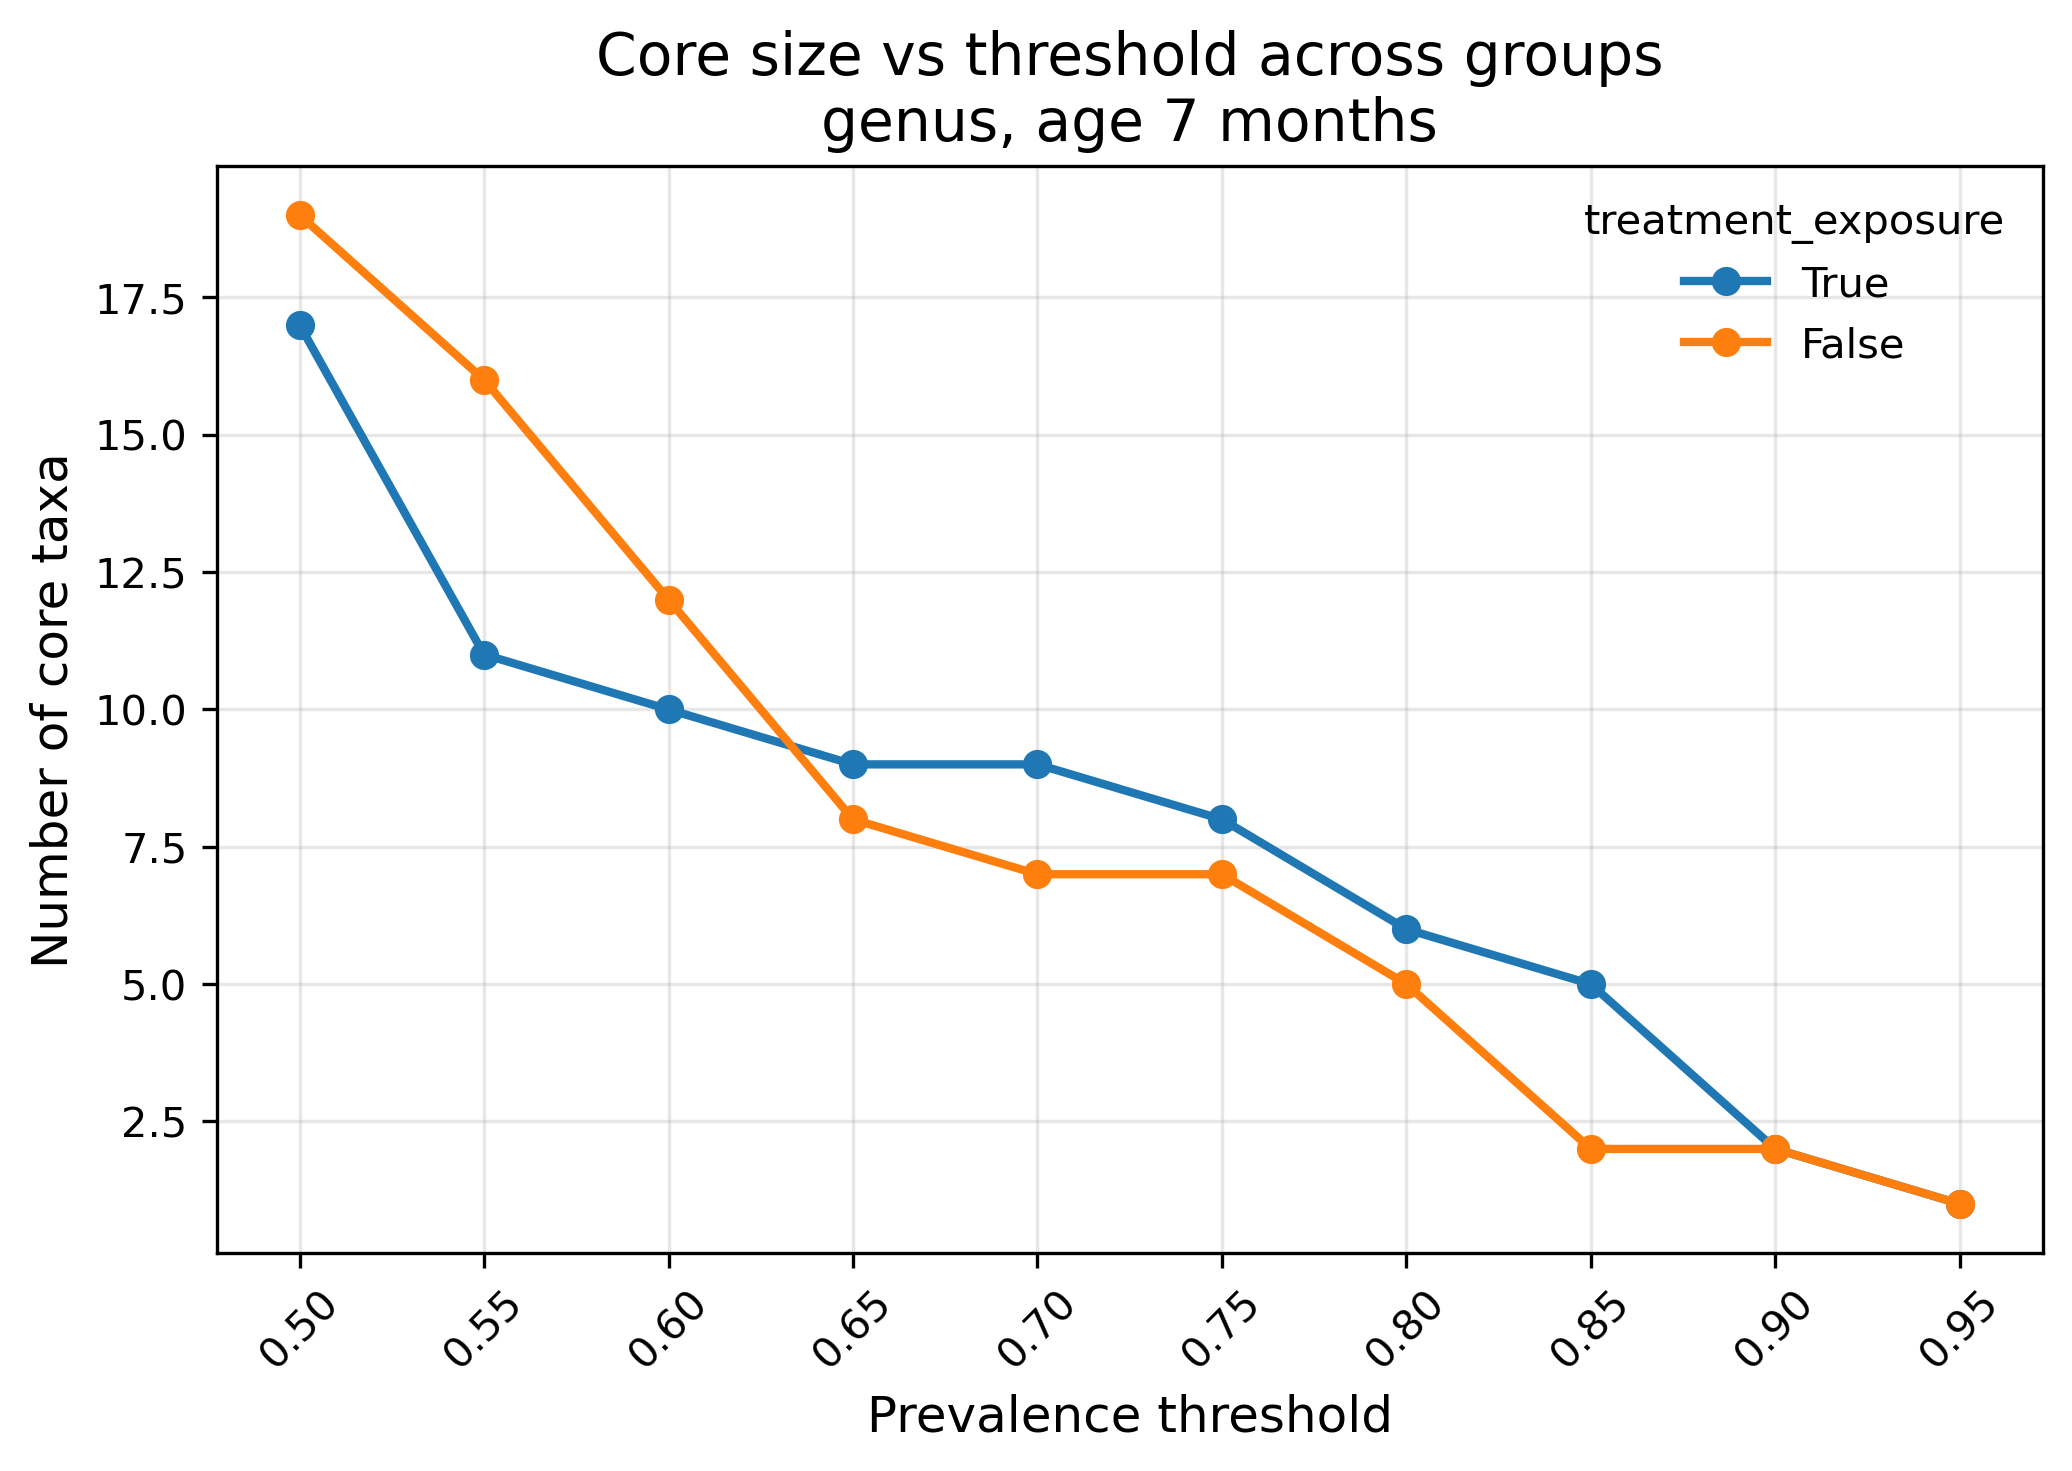

Showing: core_size_genus_treatment_exposure_age10.png


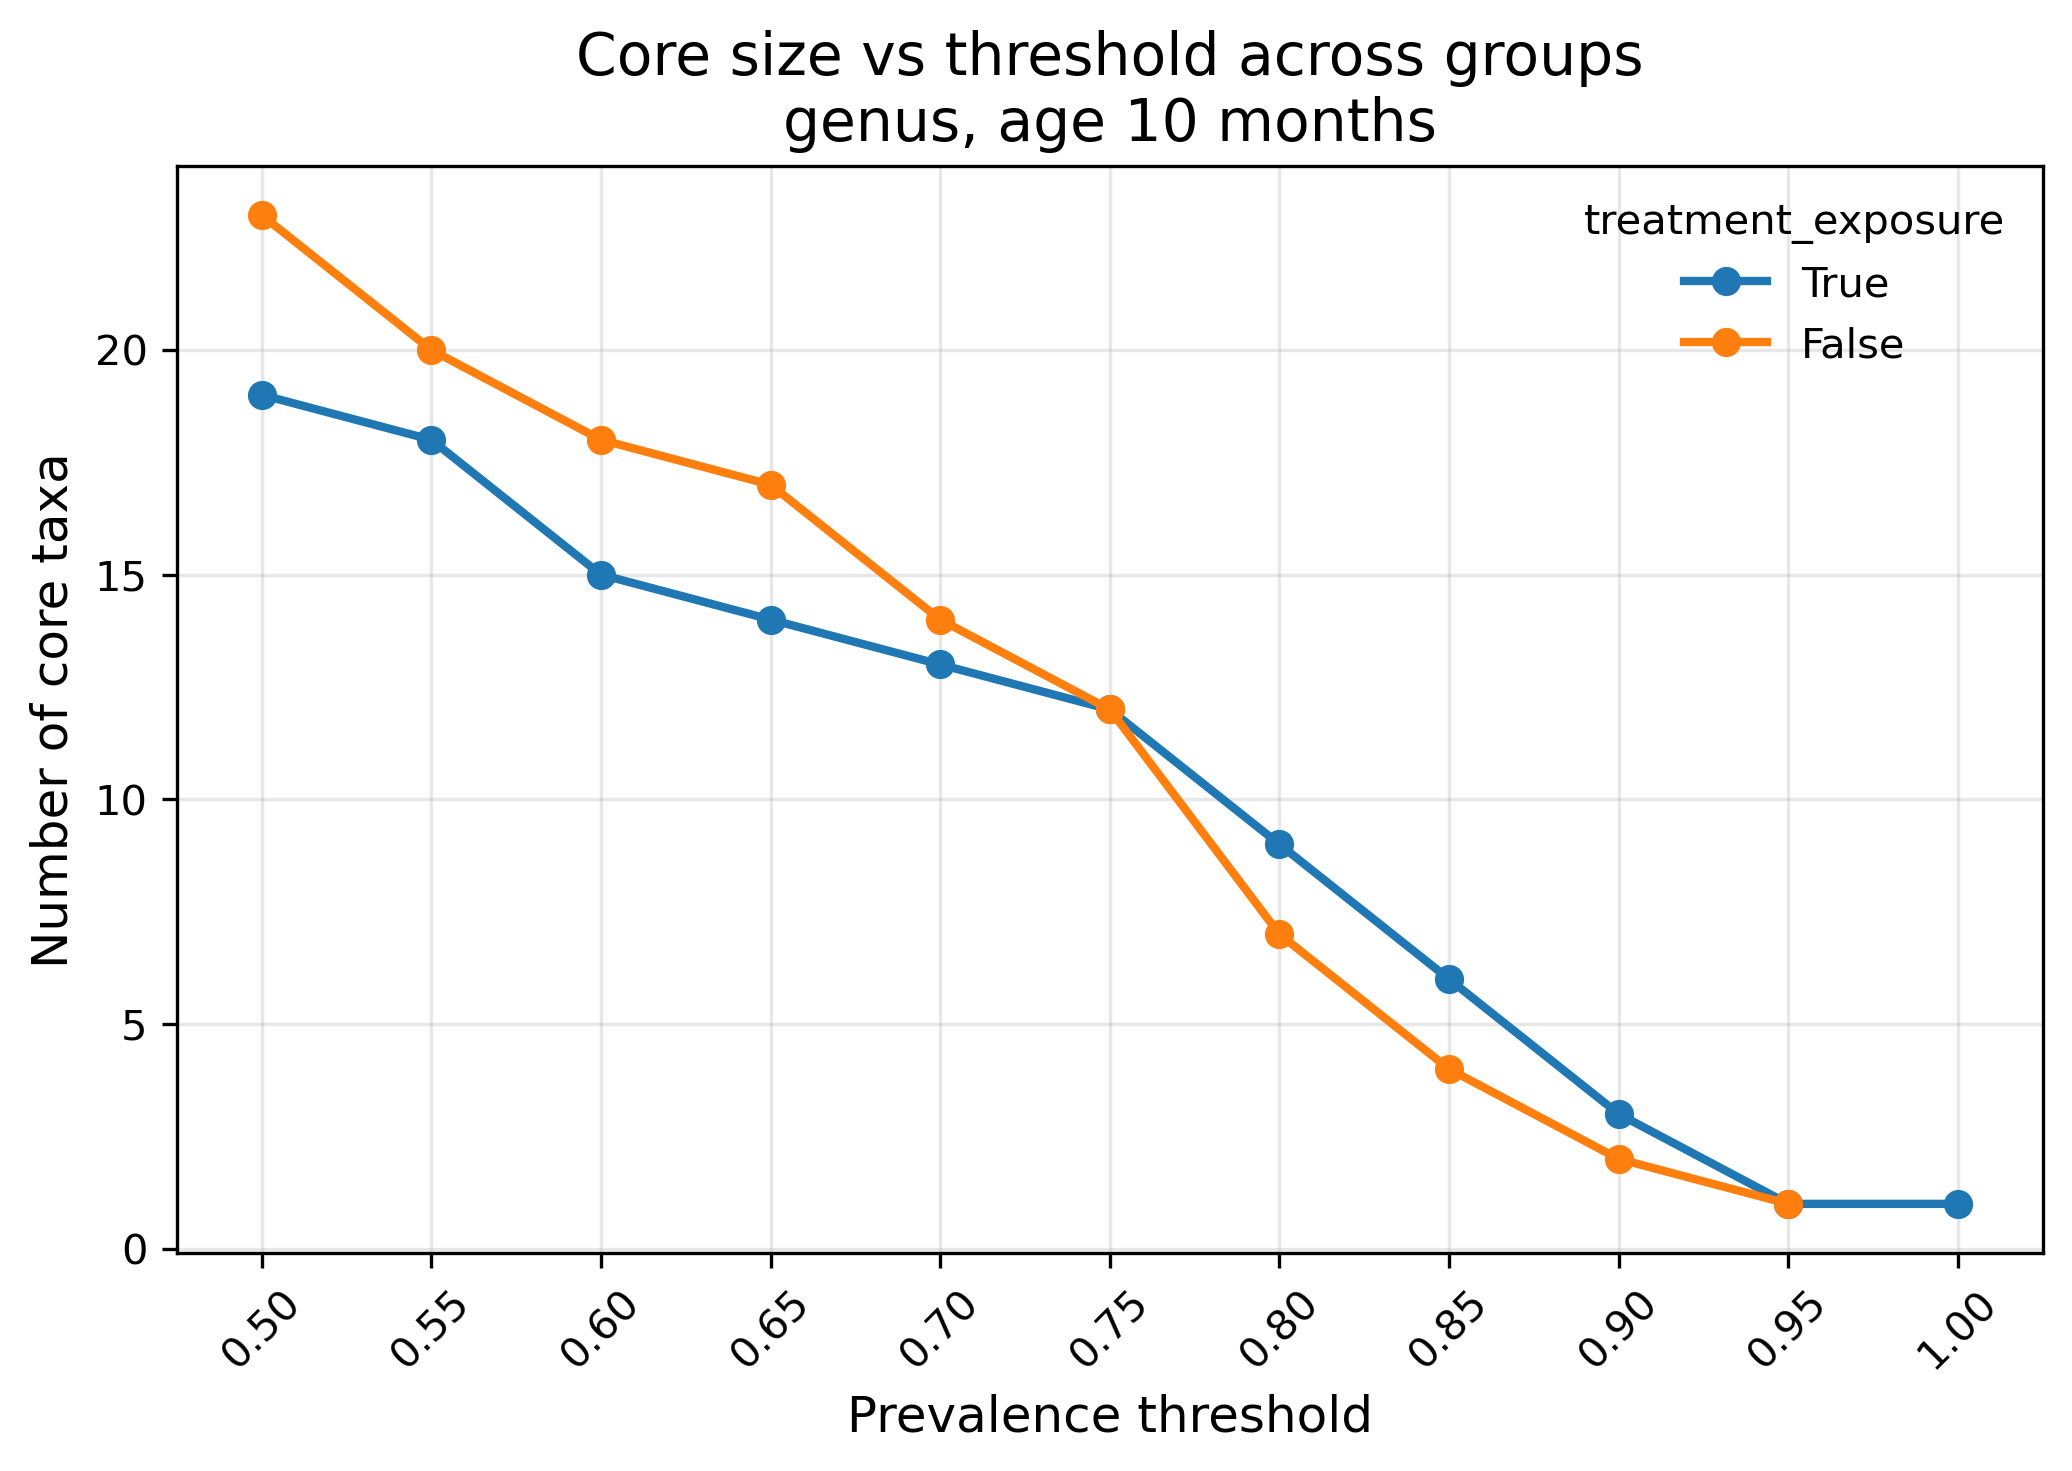

Showing: core_genus_treatment_exposure_True_vs_False_stacked.png


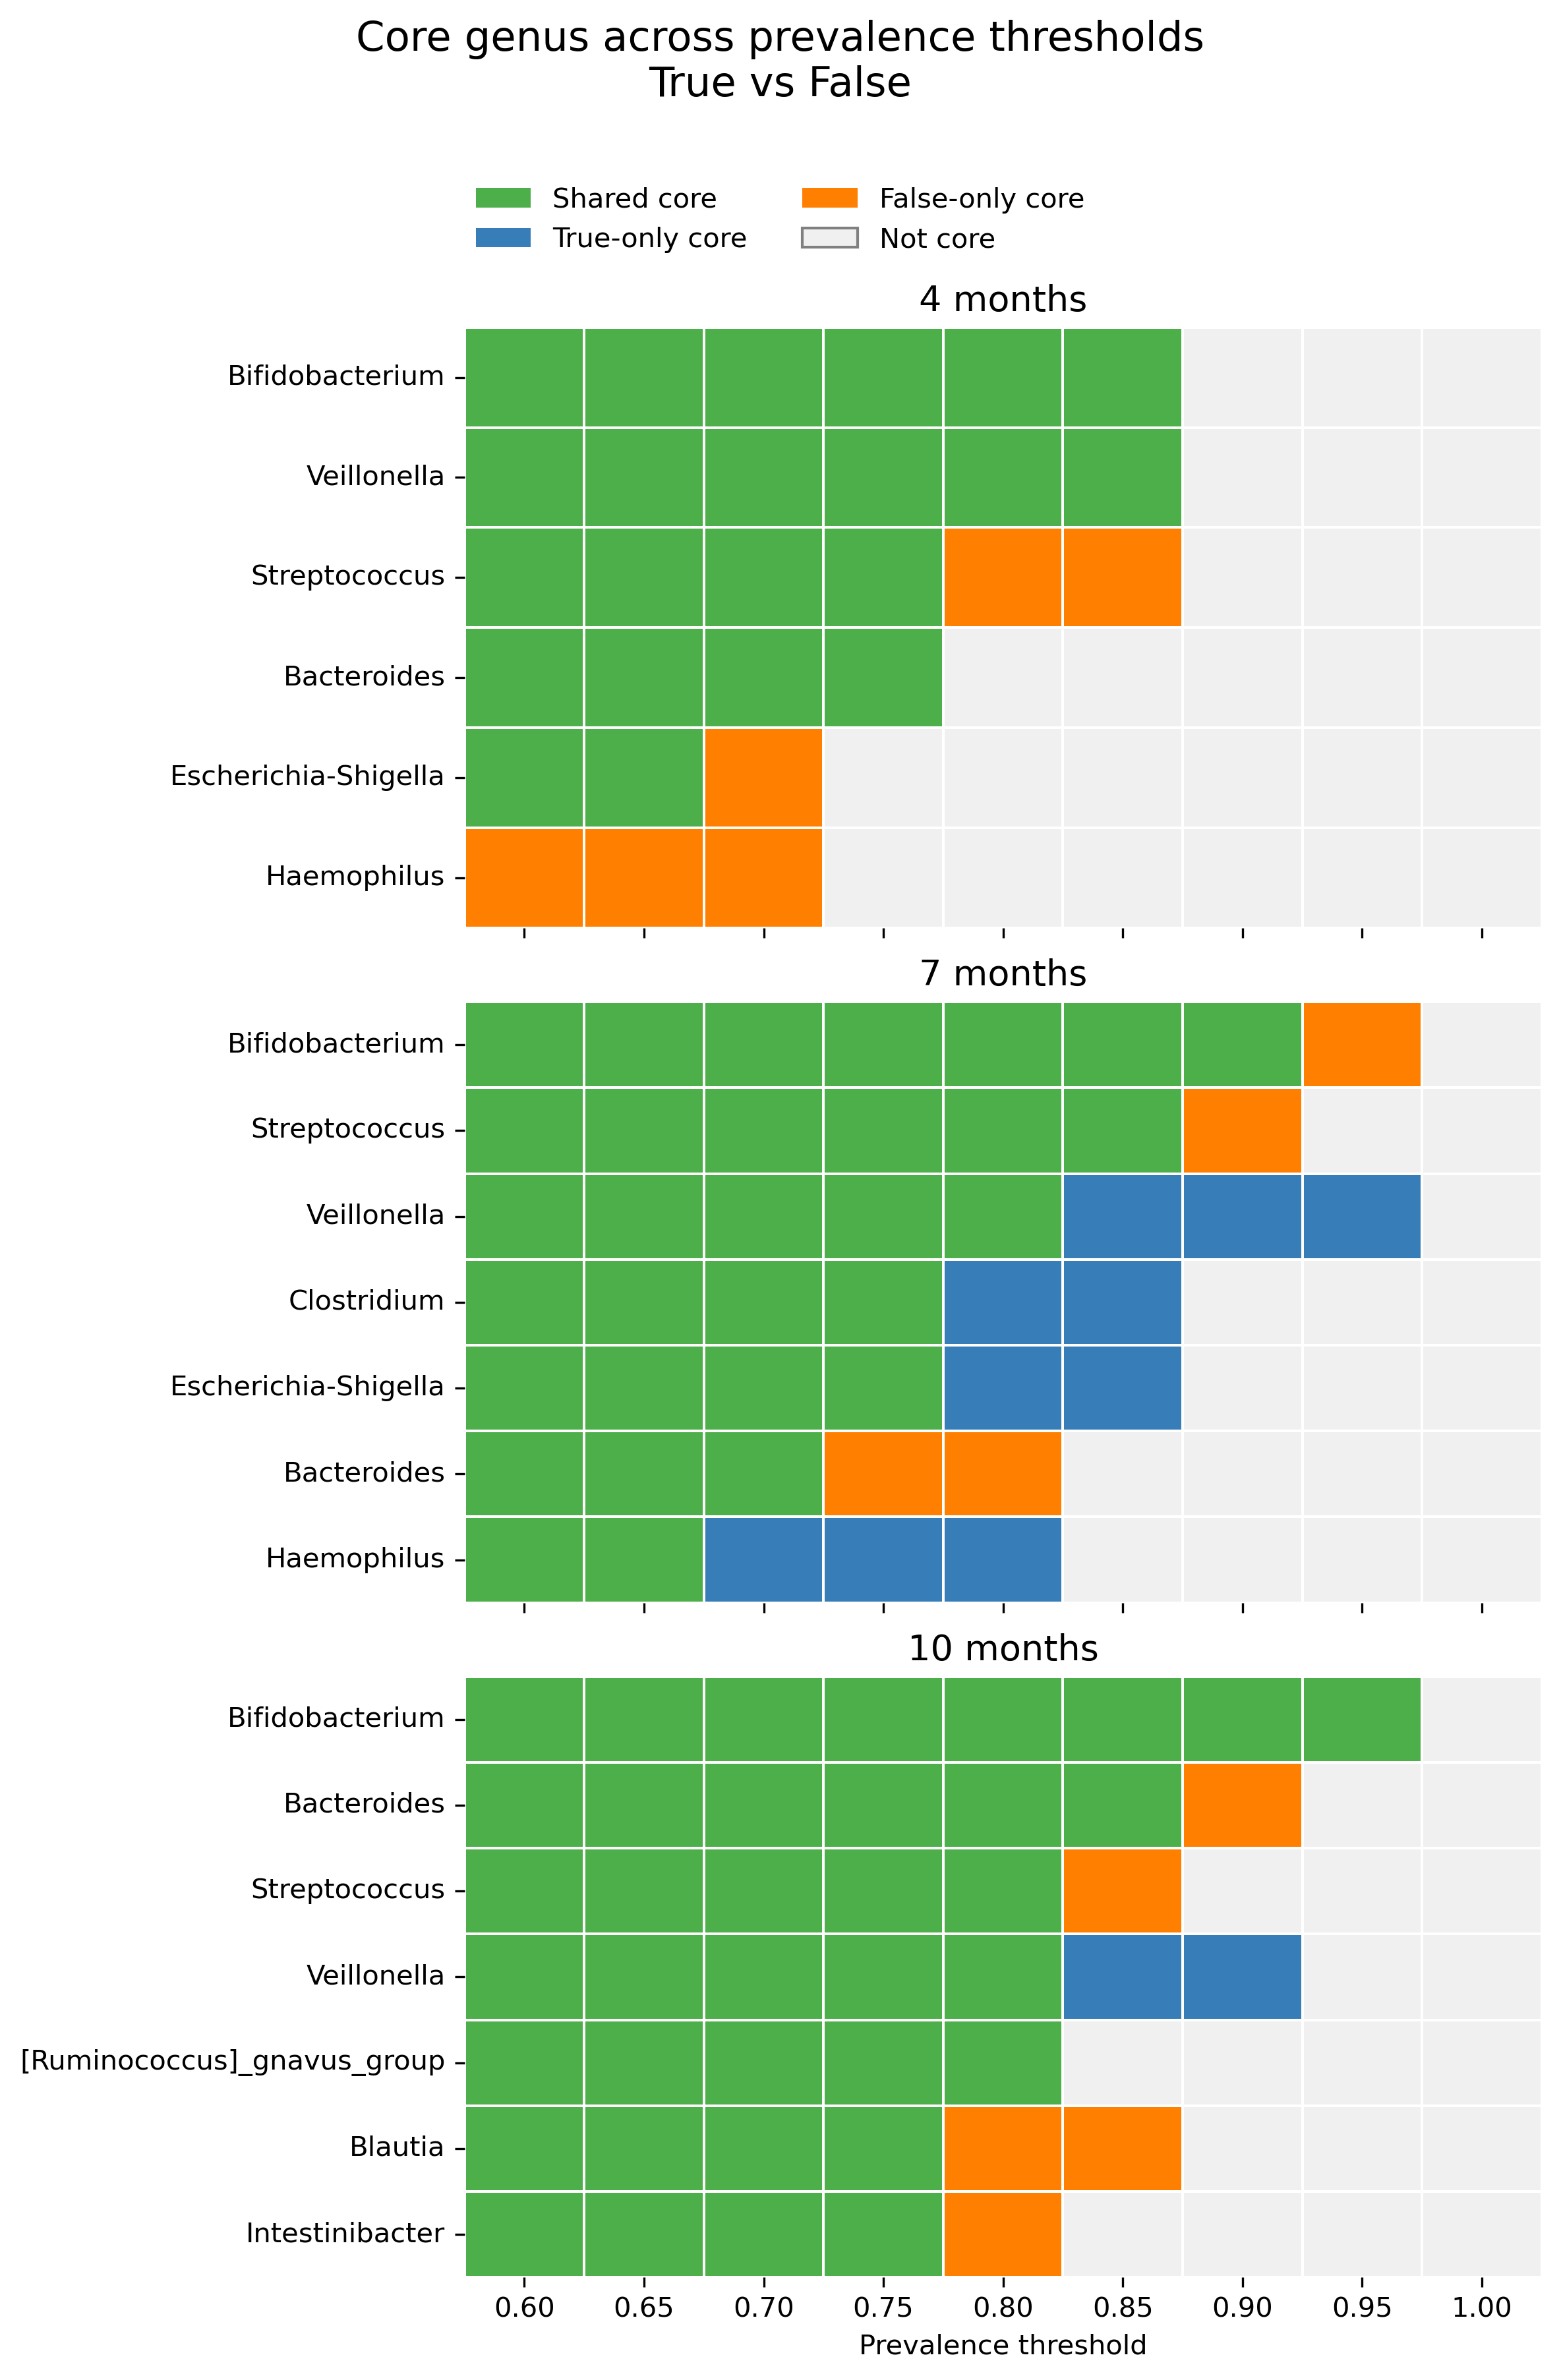

In [17]:
# # List of downloaded image files
image_files = [
    "core_size_genus_treatment_exposure_age4.png",
    "core_size_genus_treatment_exposure_age7.png",
    "core_size_genus_treatment_exposure_age10.png",
    "core_genus_treatment_exposure_True_vs_False_stacked.png"
]

# Display each image
for fname in image_files:
    path = os.path.join(core_microbiota_import_dir, fname)
    print(f"Showing: {fname}")
    display(Image(filename=path, width=900)) # adjust if needed)

This figure compares core genera between infants with and without treatment exposure (True vs. False) at 4, 7, and 10 months of age across different prevalence thresholds. Overall, the main pattern is a large overlap between the two groups, with many genera remaining shared core taxa across ages and thresholds.

At all three time points, key early-life genera such as Bifidobacterium, Bacteroides, Veillonella, and Streptococcus are largely shared between exposed and non-exposed infants, especially at lower and intermediate prevalence thresholds. This suggests that treatment exposure does not strongly change which genera dominate the infant gut microbiome. Instead, core microbiome composition seems to be mainly driven by normal age-related development rather than by exposure status.

One exception is seen at the 4-month time point, where Haemophilus is part of the core microbiome in non-treated infants but not in treated infants. One possible explanation is that some infants in the treated group received antibiotics because of infections, including respiratory infections for which Haemophilus influenzae is a known cause in young children [[Khattak & Anjum, 2023](https://www.ncbi.nlm.nih.gov/books/NBK562176/)], [[Xiao et al., 2020](https://www.nature.com/articles/s41368-020-0082-x)]. Antibiotic treatment could reduce the presence of this genus, but because little information is available about the treatment, this explanation remains speculative.

Apart from this, some genera show small or threshold-dependent differences between groups, but these patterns are not consistent across ages. For example, Escherichia–Shigella and Haemophilus appear as group-specific cores at certain thresholds at 4 or 7 months, but these differences do not last over time. At 10 months, a few genera such as Blautia or Intestinibacter also appear as group-specific cores at intermediate thresholds, again without a stable pattern across ages.

Overall, this figure suggests that treatment exposure has a limited effect on core genus membership. Most dominant genera are shared between groups, and the observed differences are small and inconsistent. However, Haemophilus may be an interesting genus to study further.

### 4.3. Comparing core microbiota of infants born vaginal or C-section

In [23]:
%%bash -s "$core_microbiota_import_dir"
mkdir -p "$1"


# import vaginal versus c-section plots
wget --progress=bar:force:noscroll \
  -O "$1/core_size_genus_delivery_mode_age4.png" \
  "https://polybox.ethz.ch/index.php/s/aBBn7z8oxFqccay/download"

wget --progress=bar:force:noscroll \
  -O "$1/core_size_genus_delivery_mode_age7.png" \
  "https://polybox.ethz.ch/index.php/s/WkbMJYqYEgqs4oM/download"
    
wget --progress=bar:force:noscroll \
  -O "$1/core_size_genus_delivery_mode_age10.png" \
  "https://polybox.ethz.ch/index.php/s/BBbxqH9ASFX386o/download"    

wget --progress=bar:force:noscroll \
  -O "$1/core_genus_delivery_mode_cesarean_vs_vaginal_stacked.png" \
  "https://polybox.ethz.ch/index.php/s/gzft3yBy3kNWFCM/download"   

--2025-12-15 20:06:00--  https://polybox.ethz.ch/index.php/s/aBBn7z8oxFqccay/download
Resolving polybox.ethz.ch (polybox.ethz.ch)... 129.132.71.243
Connecting to polybox.ethz.ch (polybox.ethz.ch)|129.132.71.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 157913 (154K) [image/png]
Saving to: ‘../data/processed/core_microbiota/imported_figures/core_size_genus_delivery_mode_age4.png’

../data/processed/c 100%[===================>] 154.21K  --.-KB/s    in 0.02s   

2025-12-15 20:06:01 (7.50 MB/s) - ‘../data/processed/core_microbiota/imported_figures/core_size_genus_delivery_mode_age4.png’ saved [157913/157913]

--2025-12-15 20:06:01--  https://polybox.ethz.ch/index.php/s/WkbMJYqYEgqs4oM/download
Resolving polybox.ethz.ch (polybox.ethz.ch)... 129.132.71.243
Connecting to polybox.ethz.ch (polybox.ethz.ch)|129.132.71.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 181443 (177K) [image/png]
Saving to: ‘../data/processed/core_microbiot

Showing: core_size_genus_delivery_mode_age4.png


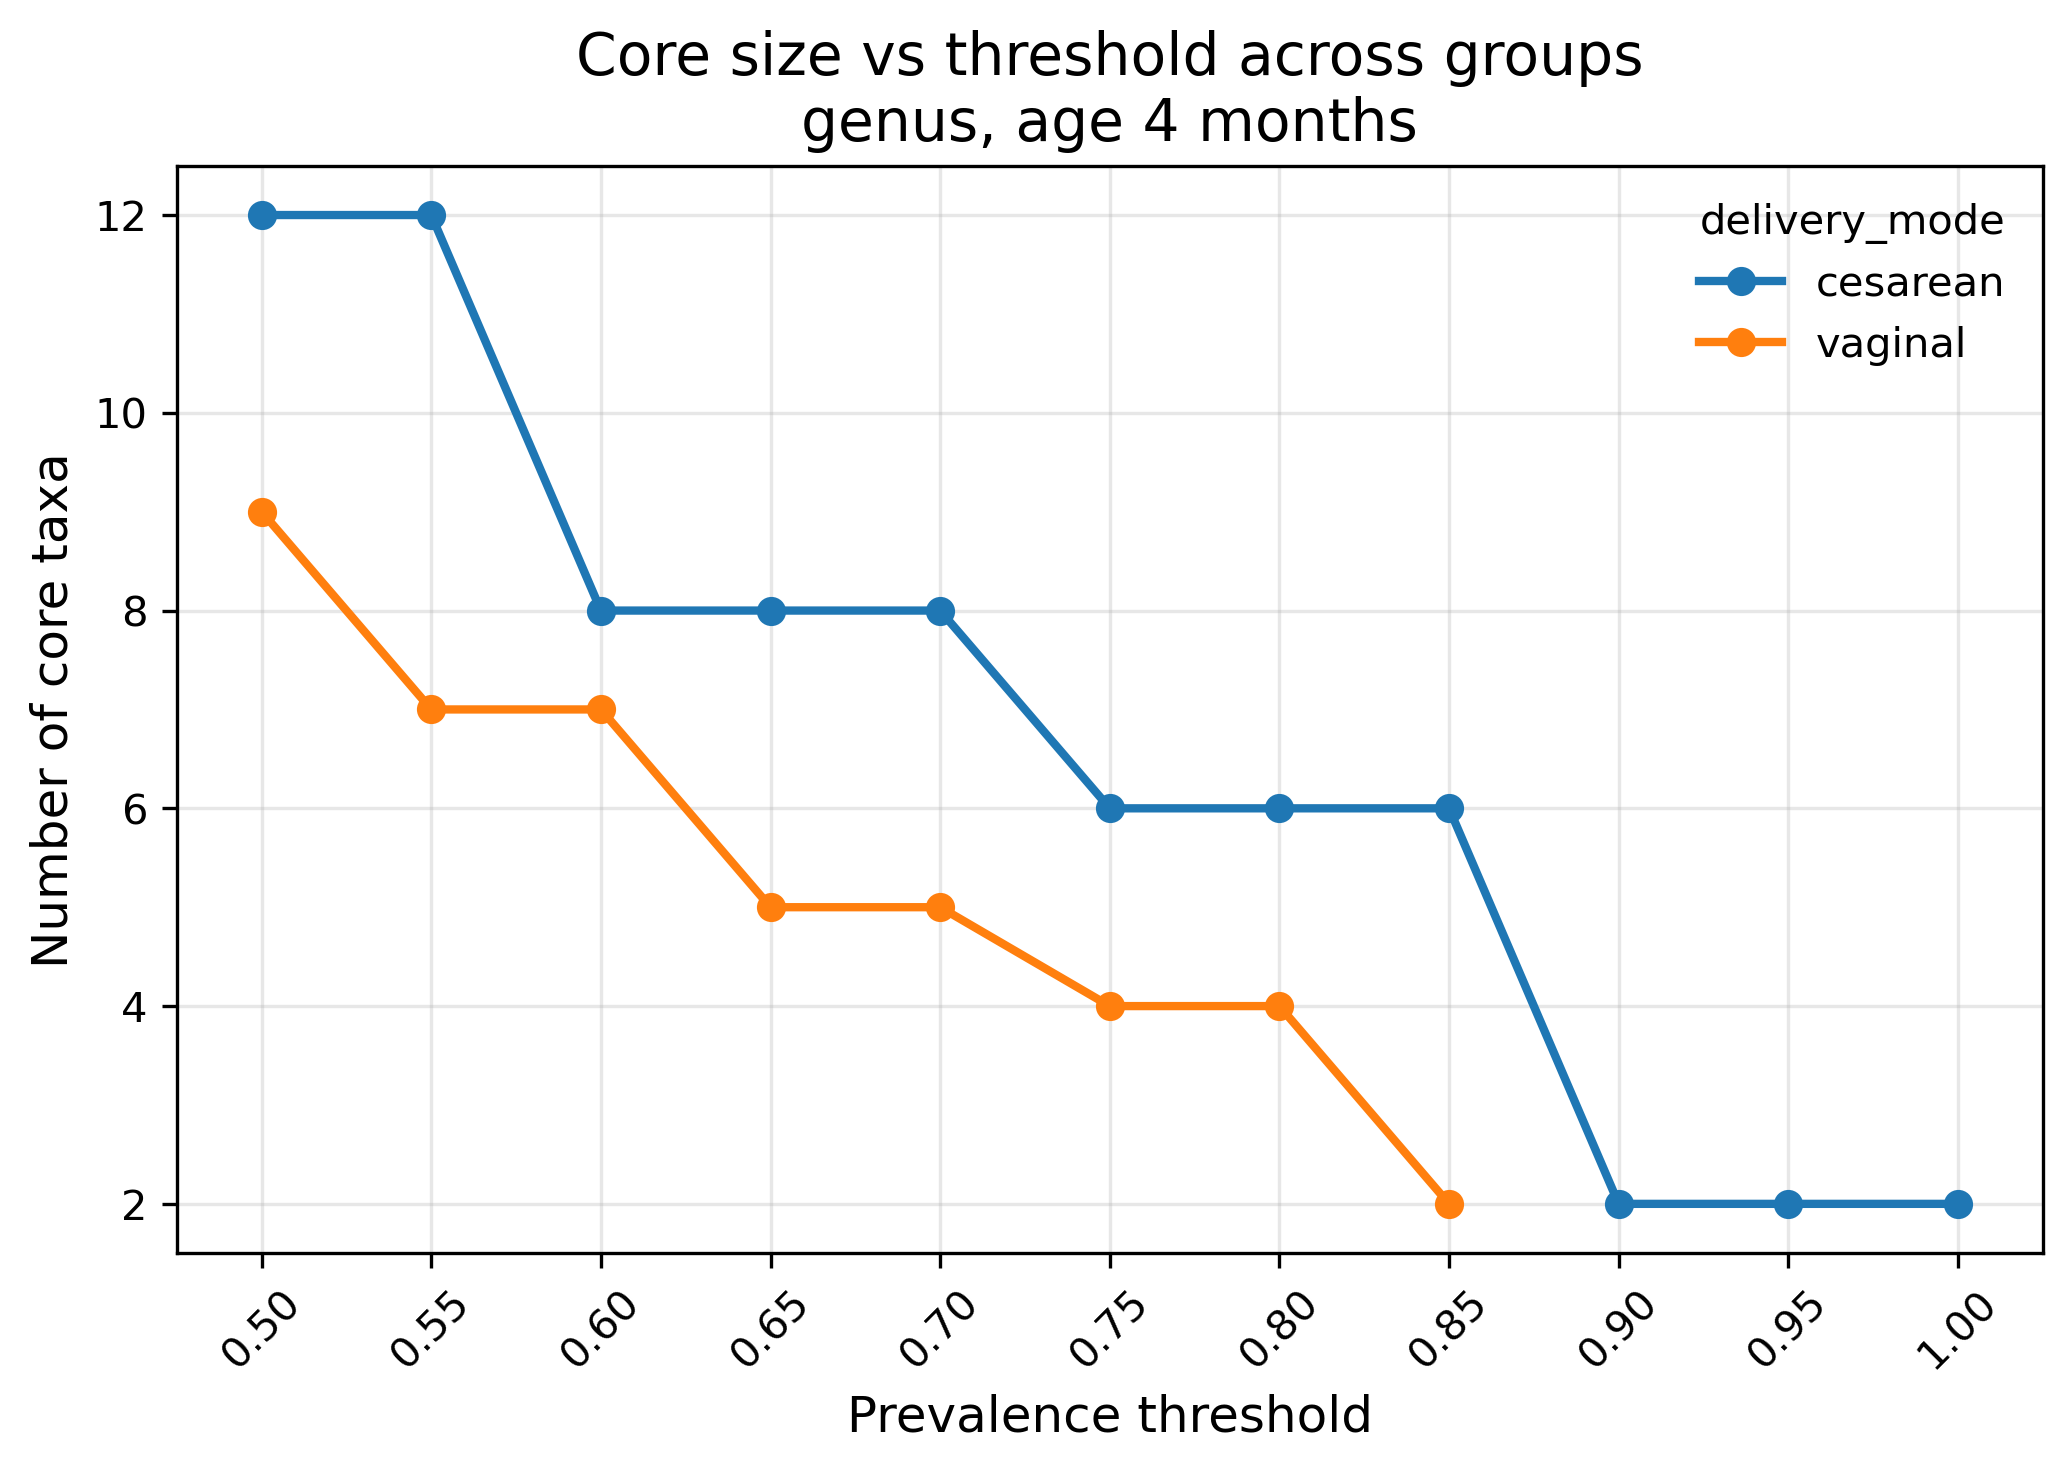

Showing: core_size_genus_delivery_mode_age7.png


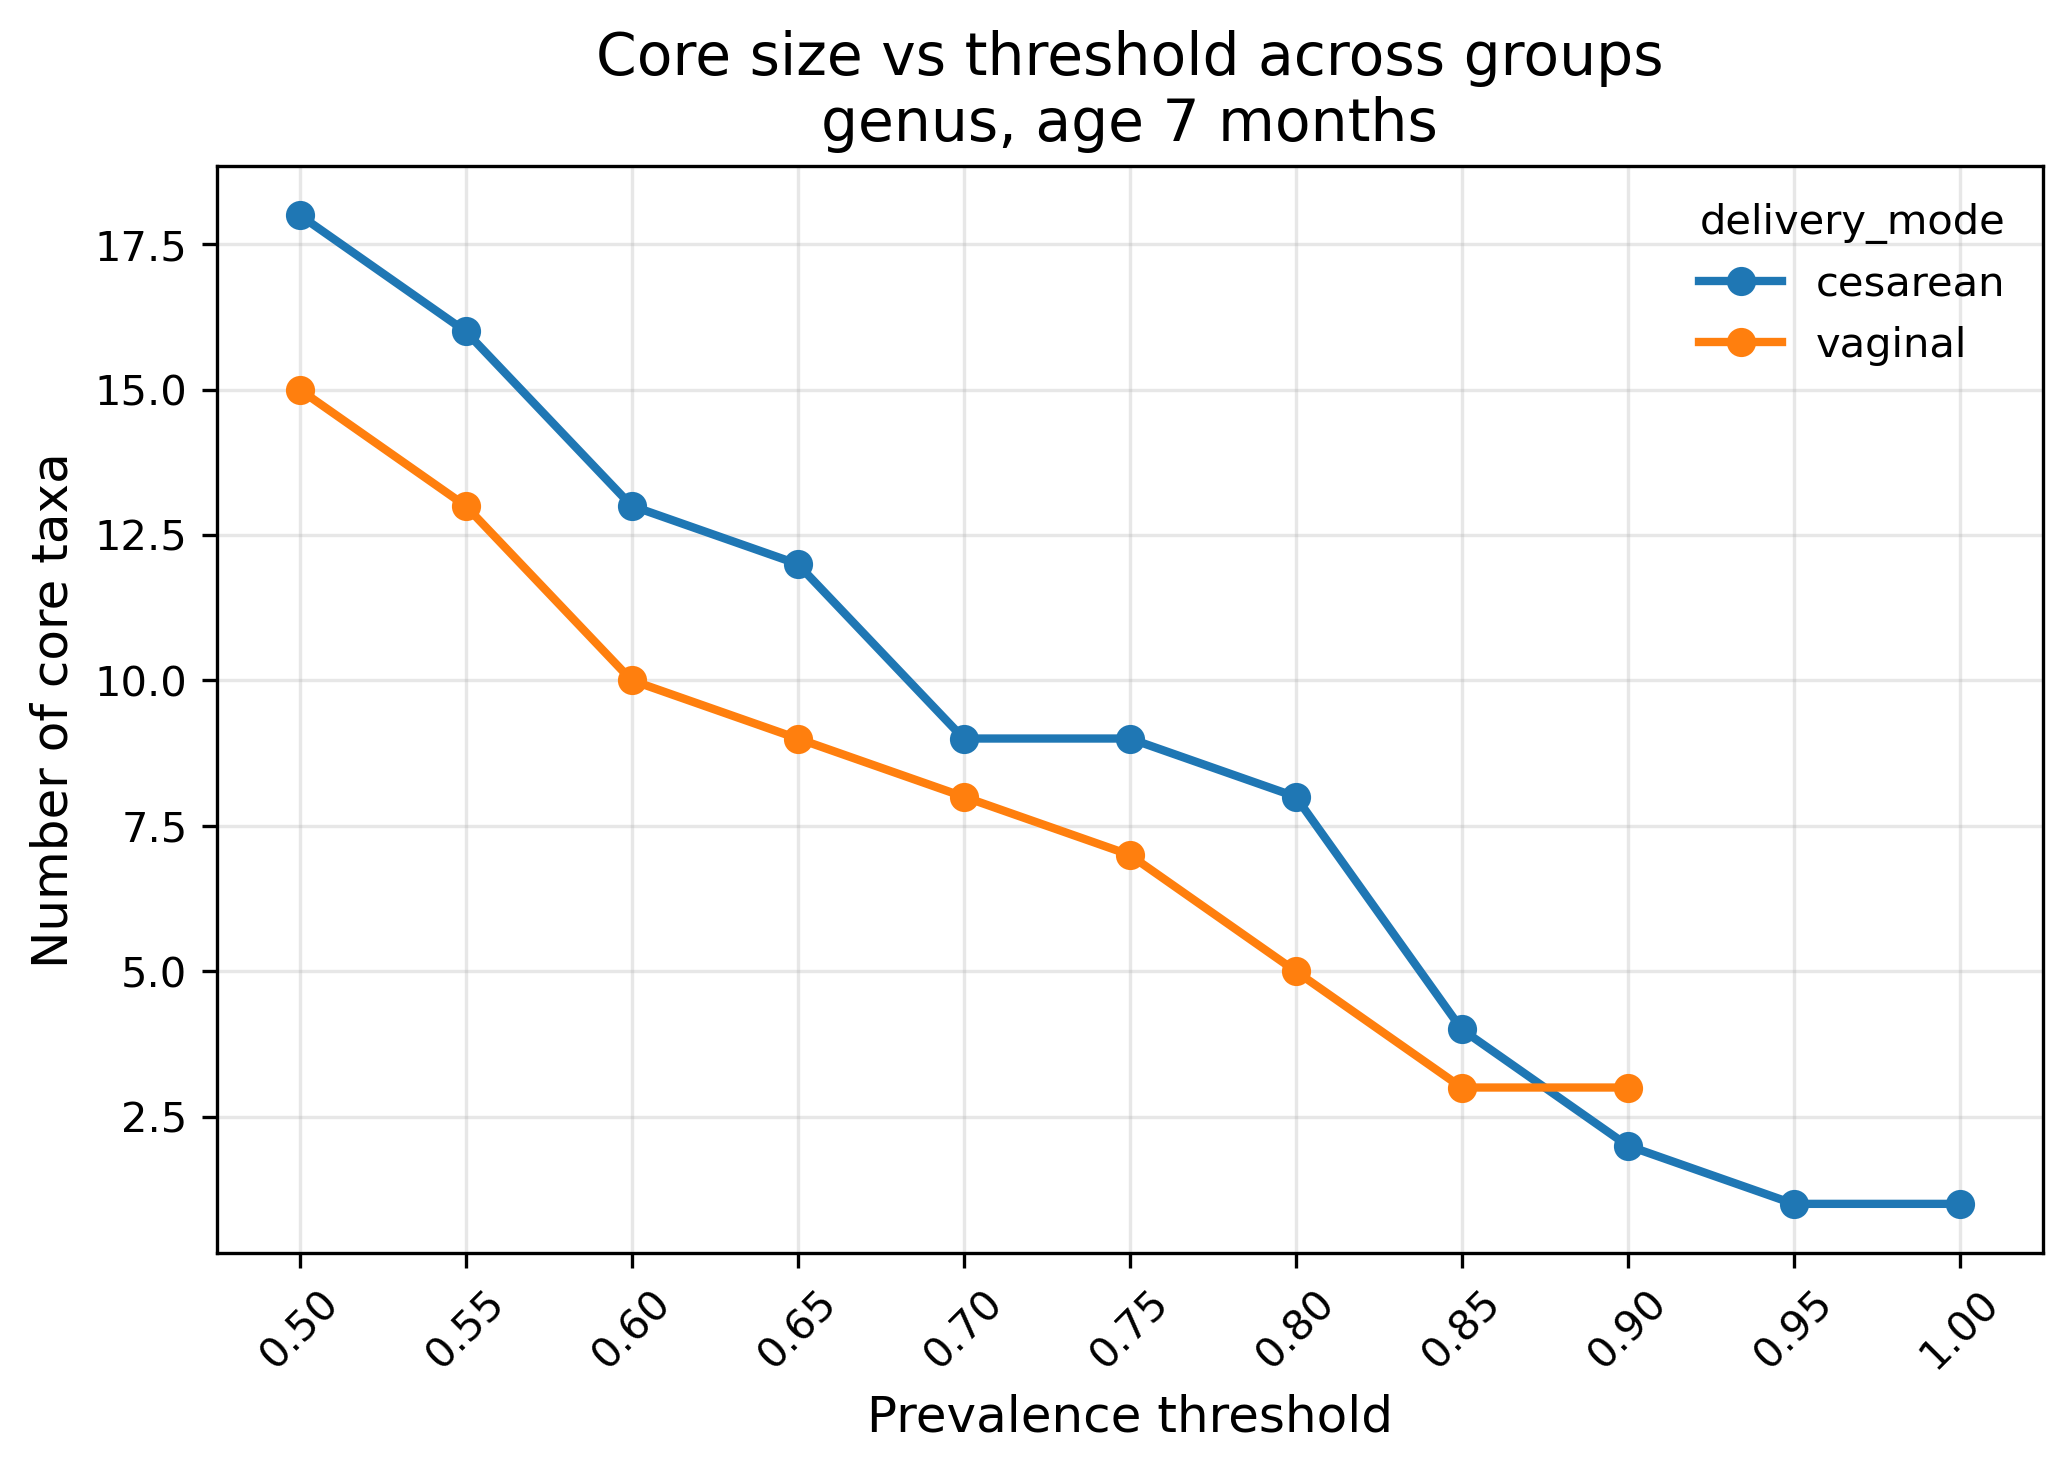

Showing: core_size_genus_delivery_mode_age10.png


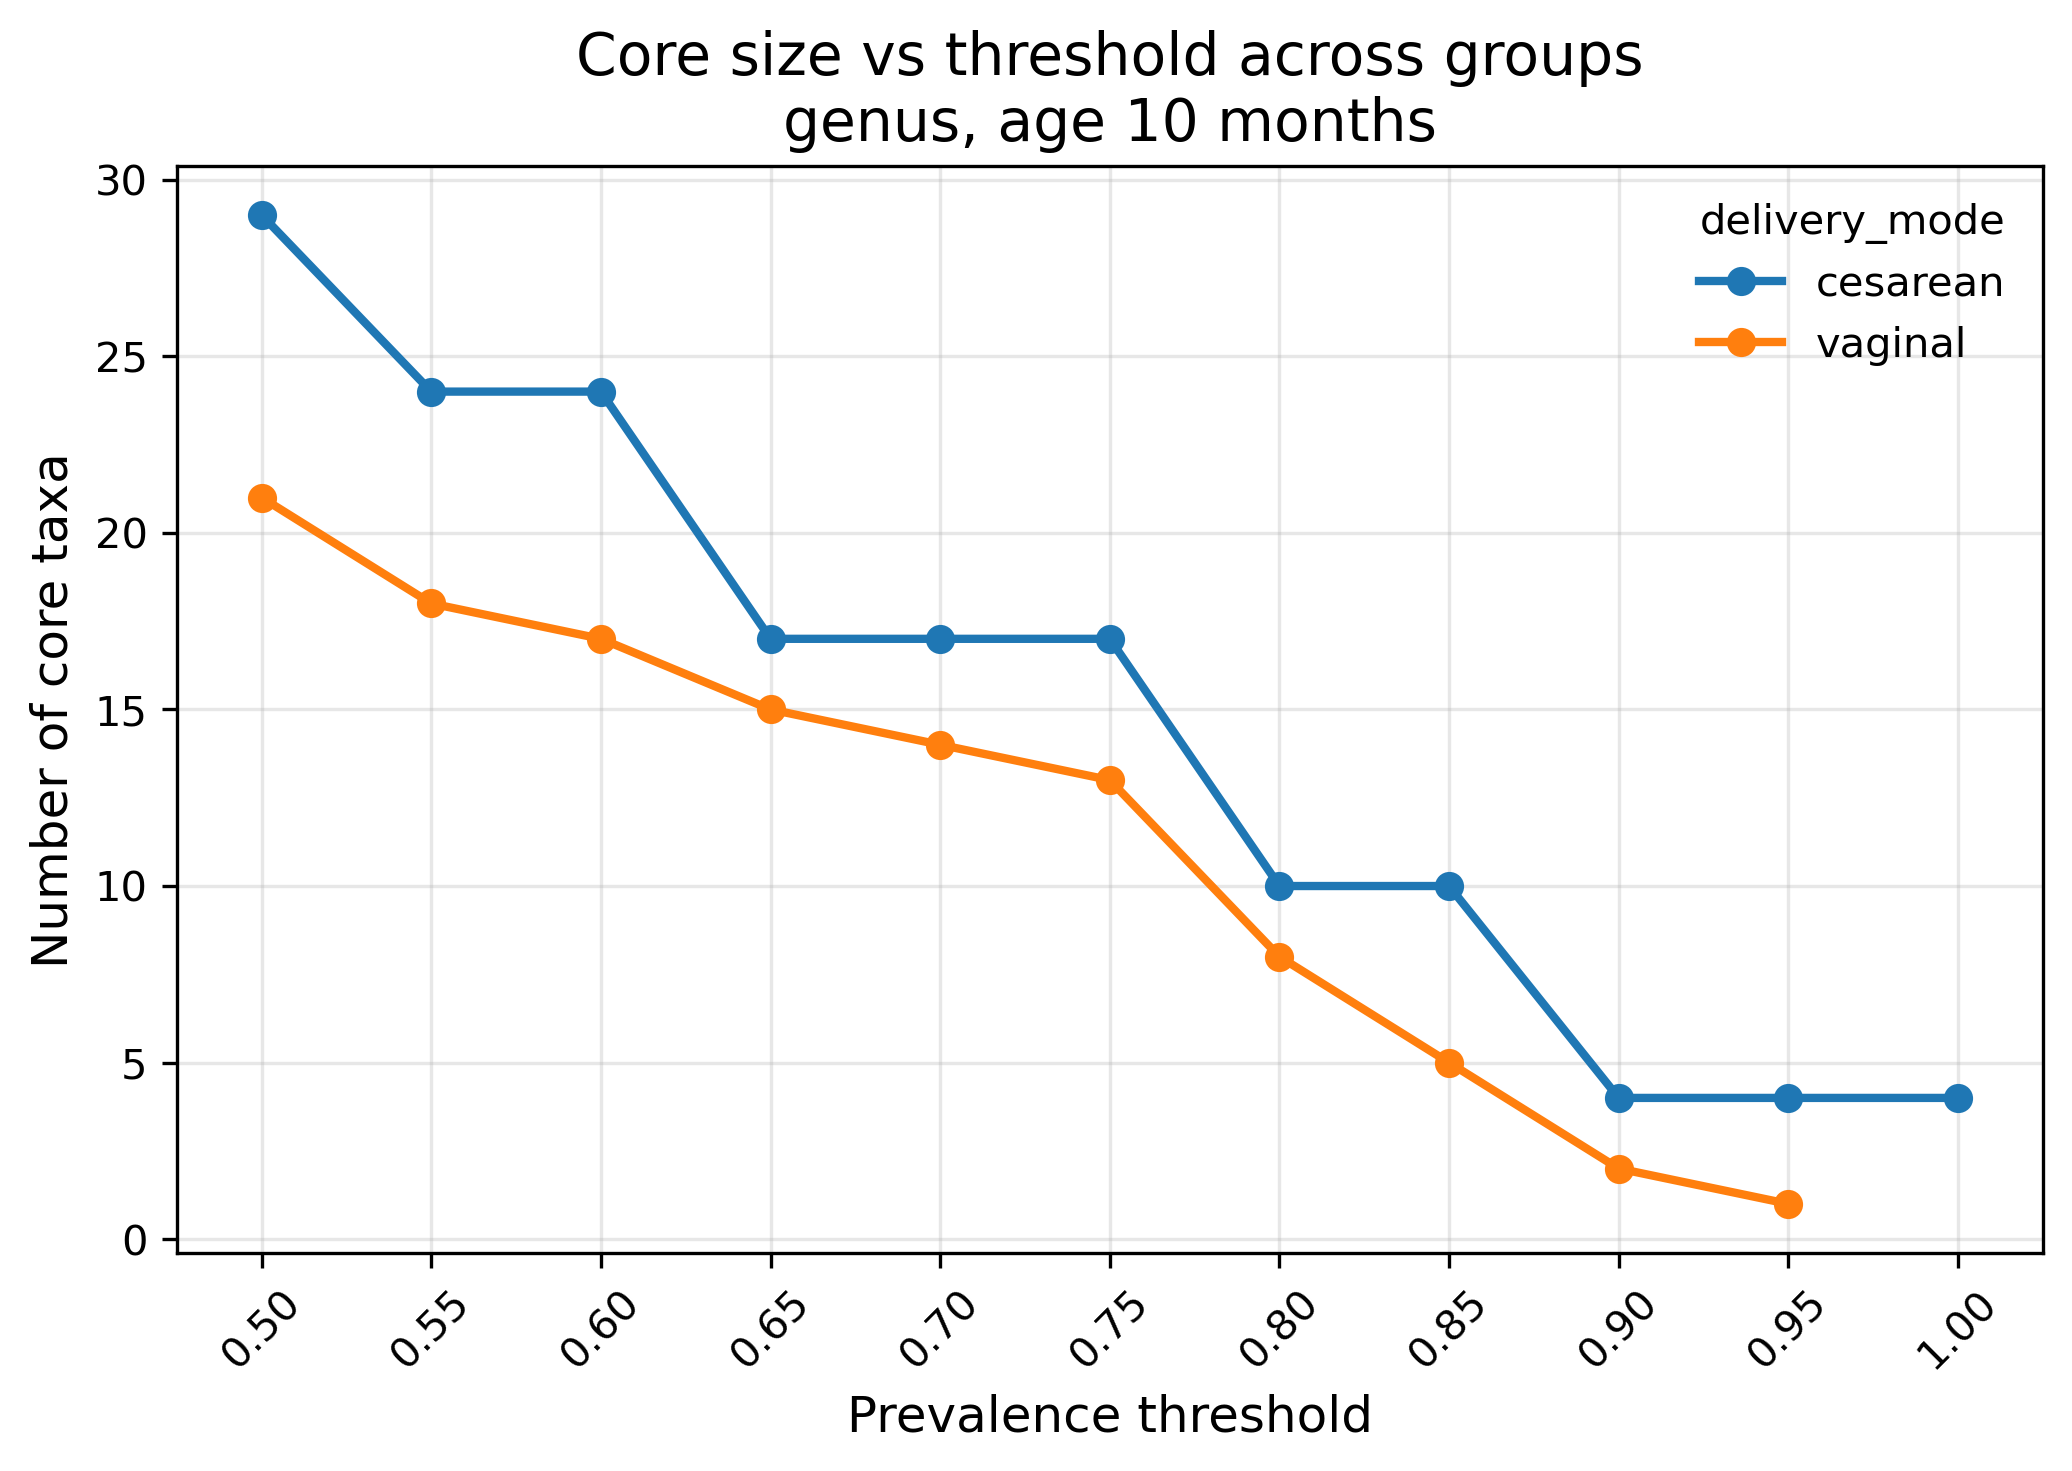

Showing: core_genus_delivery_mode_cesarean_vs_vaginal_stacked.png


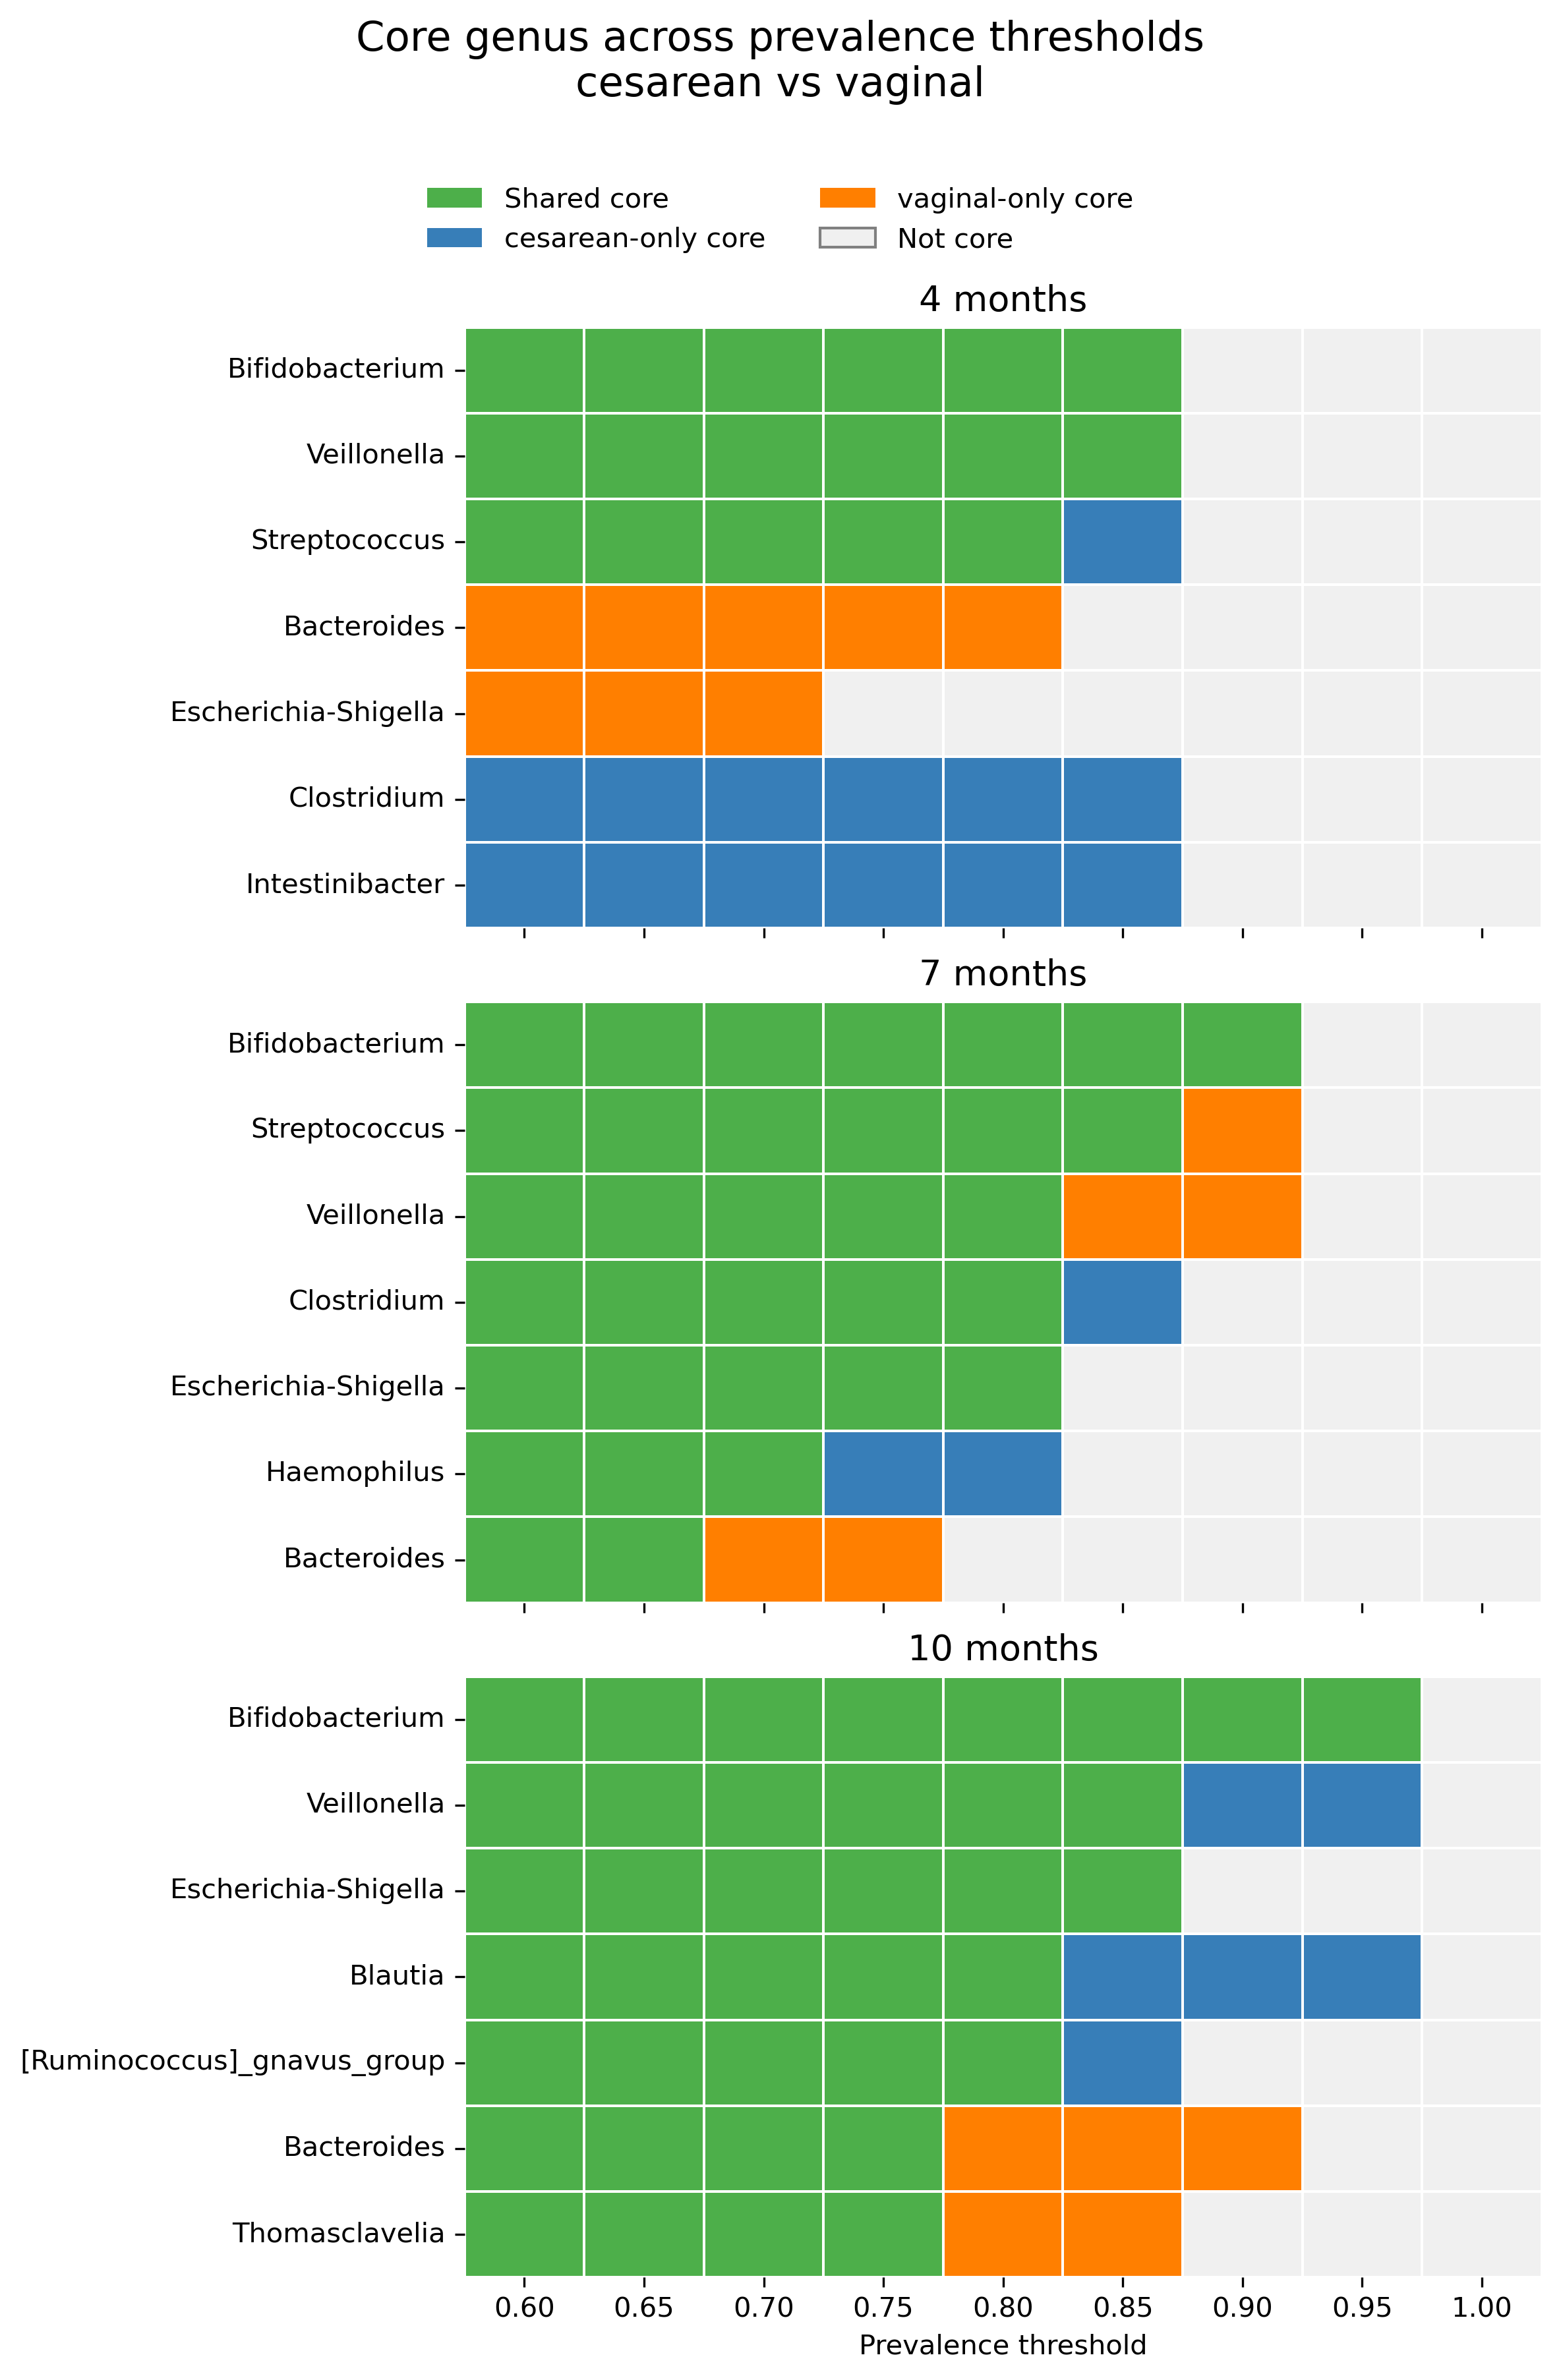

In [18]:
# List of downloaded image files
image_files = [
    "core_size_genus_delivery_mode_age4.png",
    "core_size_genus_delivery_mode_age7.png",
    "core_size_genus_delivery_mode_age10.png",
    "core_genus_delivery_mode_cesarean_vs_vaginal_stacked.png"
]

# Display each image
for fname in image_files:
    path = os.path.join(core_microbiota_import_dir, fname)
    print(f"Showing: {fname}")
    display(Image(filename=path, width=800)) # adjust if needed

This figure compares core genera between infants born by cesarean section and vaginal delivery at 4, 7, and 10 months of age across different prevalence thresholds. Overall, there is substantial overlap between the two groups, but delivery mode shows clearer and more structured differences than antibiotic exposure.

At 4 months of age, several key genera, including Bifidobacterium, Veillonella, and Streptococcus, appear as shared core taxa across most prevalence thresholds, indicating a common early-life microbiome regardless of delivery mode. At the same time, clear delivery-mode–specific patterns are visible. Bacteroides and Escherichia–Shigella appear as vaginal-only core genera at lower and intermediate thresholds, while Clostridium and Intestinibacter are consistently identified as cesarean-only core genera. This suggests that differences in microbial exposure at birth may influence which taxa establish more consistently early in life.

At 7 and 10 months of age, overlap between cesarean- and vaginally delivered infants increases, suggesting partial convergence of the gut microbiome over time. Most dominant genera are shared across groups, but some delivery-mode–specific patterns remain. For example, Bacteroides continues to show vaginal-specific core behavior at intermediate thresholds. These findings indicate that although postnatal factors such as diet and environment promote convergence, the effects of delivery mode might not be not fully eliminated by this age.

<div style="border: 2px solid #1f77b4; padding: 10px; border-radius: 6px; background-color: #eaf3fb;">
<b> Answer to the research question:</b>

- How does the core microbiota differ between groups defined by metadata variables such as feeding pattern, delivery mode, and treatment exposure?
    - **Feeding pattern:** Breastfed and formula-fed infants share many core genera at 4 months, including Bifidobacterium, Bacteroides, Veillonella, and Streptococcus. However, some diet-related differences are observed, such as Escherichia–Shigella appearing more consistently in formula-fed infants at higher prevalence thresholds, while it is not part of the breastfed core.

    - **Delivery mode:** Infants born by vaginal delivery and cesarean section show substantial overlap in core microbiota, but delivery mode is associated with clearer and more stable differences, especially at earlier ages. Bacteroides is more often associated with vaginal delivery, whereas Clostridium and Intestinibacter are more frequently associated with cesarean delivery.

    - **Treatment exposure:** Infants with and without treatment exposure largely share the same core genera across ages, indicating a limited overall impact of treatment on core microbiota composition. However, the absence of Haemophilus from the core microbiome of treated infants at 4 months is an interesting observation.

</div>

# References

National Cancer Institute, Center for Cancer Research. QIIME 2: Lesson 7 — Identifying Core Microbiota. https://bioinformatics.ccr.cancer.gov/docs/qiime2/Lesson7/

QIIME 2 Documentation. (2024). core-features: Identify features present in a user-defined fraction of samples. https://docs.qiime2.org/2024.10/plugins/available/feature-table/core-features/

StatPearls Publishing. (2023). Haemophilus influenzae infection. Khattak, Z. E., & Anjum, F. https://www.ncbi.nlm.nih.gov/books/NBK562176/

Xiao, J., Fiscella, K. A., & Gill, S. R. (2020). Oral microbiome: possible harbinger for children’s health. International Journal of Oral Science, 12, Article 12.
https://www.nature.com/articles/s41368-020-0082-x

Fehr, K., Moossavi, S., Sbihi, H., Boutin, R. C. T., Bode, L., Robertson, B., … Azad, M. B. (2020). Breastmilk feeding practices are associated with the co-occurrence of bacteria in mothers’ milk and the infant gut: The CHILD cohort study. Cell Host & Microbe, 28(2), 285–297.e4. https://www.sciencedirect.com/science/article/pii/S1931312820303504